# CH4 gap-filling: EDA -> feature imputation -> feature engineering -> gap-filling -> UQ

**Purpose.** A condensed, restructured version of `temp_gap_filing_exploration copy.ipynb`,
reorganised into five logical stages so it can be extended with new experiments. No functions
are imported from `src/` -- every transformation is reproduced inline, so this notebook has
zero dependencies beyond the raw data files under `data/`. All core methodology, constants,
and code are unchanged from the source notebook; only structure and narrative are condensed.
The "extended exploration" battery from the source notebook (alternative estimators, soil/target
lag ablations, PCA/TICA, Kalman demo, prediction-interval/conformal calibration work) is **not**
reproduced here -- this notebook is the standing base pipeline those experiments were run on top
of, kept lean specifically so new experiments can be added cleanly.

**Target result** (must reproduce, `BEST_RESULTS.md` section 1, D-35/D-48/D-49):

| Tower | RFm (partial-pooled, external-sourced) R2 |
|---|---|
| 2 | 0.574 |
| 4 | 0.402 |
| 9 | 0.418 |

**Methodology in one line.** A partially-pooled (T2+T4+T9, with tower-indicator dummies) Random
Forest, trained on **external-sourced** (Site MET + per-catchment SMS soil sensors) meteorological
drivers, gap-filled REddyProc-style, plus a reconstructed CO2 flux (FCO2) feature, livestock
stocking density, management-event recency, and soil moisture/temperature lags -- evaluated under
**full-period gap-CV** (synthetic calendar gaps across each tower's entire valid domain, not a
train/test year split -- F-07/D-34 found year splits catastrophically fail for Tower 2).

**Structure:**
1. **EDA** -- data-quality issues and the fix each one drives downstream.
2. **Feature imputation** -- FCO2 reconstruction, external sensor sourcing, meteorological
   driver gap-filling (with a held-out accuracy check).
3. **Additional feature engineering** -- GPP/Reco partitioning, management recency, livestock
   density, and final feature-frame assembly.
4. **Gap-filling** -- the full-period gap-CV harness (MDS vs. RFm-solo vs. RFm-pooled), results,
   a daily-resolution accuracy check, and a production gap-filled series.
5. **Uncertainty quantification** -- Area-of-Applicability dissimilarity index, validated against
   held-out error and applied to the production series.

## 0. Setup

In [1]:
from pathlib import Path
import datetime
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

import functools
from collections import defaultdict

TIMING_STATS = defaultdict(lambda: {"calls": 0, "total_s": 0.0})


def timeit(func):
    """Accumulates call count + total wall time per function into TIMING_STATS (no per-call
    print -- functions here range from called-once RF fits to called-hundreds-of-times helpers,
    so printing per call would flood cell output). See print_timing_summary() for the report."""
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        t0 = time.perf_counter()
        result = func(*args, **kwargs)
        dt = time.perf_counter() - t0
        stats = TIMING_STATS[func.__name__]
        stats["calls"] += 1
        stats["total_s"] += dt
        return result
    return wrapper


def print_timing_summary(top_n=None):
    """Prints every @timeit-decorated function's call count / total time / mean time per call,
    sorted by total time descending -- run any time to see where time is actually going."""
    rows = sorted(TIMING_STATS.items(), key=lambda kv: -kv[1]["total_s"])
    if top_n:
        rows = rows[:top_n]
    print(f'{"function":32s} {"calls":>8s} {"total_s":>10s} {"avg_ms":>10s}')
    for name, s in rows:
        avg_ms = 1000 * s["total_s"] / max(s["calls"], 1)
        print(f'{name:32s} {s["calls"]:8d} {s["total_s"]:10.2f} {avg_ms:10.2f}')


HOURLY = Path("../../data/Hourly")
COMPILED = Path("../../data/Compiled")
RESULTS = Path("../../results")

TOWERS = [2, 4, 9]
C4 = "Catchment 4 After  2013/08/13"           # Tower 4's catchment column suffix (note double space)
CAT = {2: "Catchment 2", 4: C4, 9: "Catchment 9"}   # Tower N = Catchment N (D-18)
AREA = {2: 6.65, 4: 7.75, 9: 7.75}             # fenced catchment area, hectares (Appendix D)

print("Setup complete.")

Setup complete.


## 1. EDA

Works through the data-quality issues that shape the methodology, in the order they matter for
gap-filling: index integrity, target availability/outliers, spatial-alignment, driver sourcing,
sensor contamination, Tower 2's regime shift, and FC (CO2 flux) coverage. Each subsection ends
with the fix implemented downstream; section 1.10 tabulates all of them.

### 1.1 Load raw hourly data

`consolidated_hourly.csv` is the 1-hour, all-sources outer-joined table (EC tower fluxes/met,
catchment flow + soil moisture/temperature, per-catchment livestock counts) on one continuous
`Datetime` index -- the true starting point; everything else (including the external-sourced
variant) is derived from it below.

In [2]:
raw = pd.read_csv(HOURLY / "consolidated_hourly.csv", low_memory=False)
raw["Datetime"] = pd.to_datetime(raw["Datetime"], format="mixed")
raw = raw.set_index("Datetime")

print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} cols")
print(f"Span:  {raw.index.min()} -> {raw.index.max()}")
raw.iloc[:3, :6]

Shape: 70,153 rows x 449 cols
Span:  2017-01-01 00:00:00 -> 2025-01-02 00:00:00


,CO2_1_1_1 [Tower 2],H2O_1_1_1 [Tower 2],CH4_1_1_1 [Tower 2],TAU_1_1_1 [Tower 2],TAU_SSITC_TEST_1_1_1 [Tower 2],H_1_1_1 [Tower 2]
Datetime,,,,,,
2017-01-01 00:00:00,373.002829,2.582062,NaN,0.069802,0.0,-17.133901
2017-01-01 01:00:00,370.941935,2.625380,NaN,0.107350,0.0,-28.424088
2017-01-01 02:00:00,371.457921,2.631636,NaN,0.093147,0.0,-18.809984


### 1.2 Index integrity

In [3]:
full_range = pd.date_range(raw.index.min(), raw.index.max(), freq="h")
print("Monotonic increasing:      ", raw.index.is_monotonic_increasing)
print("Duplicate timestamps:      ", raw.index.duplicated().sum())
print("Missing hourly timestamps: ", len(full_range.difference(raw.index)))
print("Overall NaN share:         ", f"{100 * raw.isna().mean().mean():.1f}%")

Monotonic increasing:       True
Duplicate timestamps:       0
Missing hourly timestamps:  0
Overall NaN share:          39.4%


**Result:** the hourly index is already continuous and duplicate-free (an artefact of
`consolidate_hourly.py`'s reindexing) -- every "gap" in this project is a `NaN`, not a missing row.

### 1.3 Target (FCH4) availability and quality flag -- the actual gap-filling problem

In [4]:
for t in TOWERS:
    tgt, ssitc = f"FCH4_1_1_1 [Tower {t}]", f"FCH4_SSITC_TEST_1_1_1 [Tower {t}]"
    valid_pct = 100 * raw[tgt].notna().mean()
    flag_counts = raw[ssitc].value_counts(dropna=False).sort_index()
    print(f"Tower {t}: {valid_pct:5.1f}% raw-valid FCH4  |  SSITC flag counts: {flag_counts.to_dict()}")

Tower 2:  11.5% raw-valid FCH4  |  SSITC flag counts: {0.0: 2759, 0.5: 1537, 1.0: 2149, 1.5: 1027, 2.0: 627, nan: 62054}
Tower 4:  43.5% raw-valid FCH4  |  SSITC flag counts: {0.0: 11903, 0.5: 5924, 1.0: 7580, 1.5: 3073, 2.0: 2007, nan: 39666}
Tower 9:  25.0% raw-valid FCH4  |  SSITC flag counts: {0.0: 6842, 0.5: 3347, 1.0: 4414, 1.5: 1851, 2.0: 1055, nan: 52644}


**Fix:** keep `FCH4_SSITC_TEST` (0=best/1=acceptable/2=reject) in `{0, 1}` only (Irvin 2021 / Zhu
2023a convention). `CH4_1_1_1 [Tower N]` is the CH4 **mole fraction**, not the flux -- never used
as a target/feature.

### 1.4 Target outliers -- physically implausible FCH4 values

Tower 2: SSITC-passed range [-6351, 696049] nmol m-2 s-1, 18 points outside [-500, 3000]
Tower 4: SSITC-passed range [-248836, 473944000] nmol m-2 s-1, 14 points outside [-500, 3000]
Tower 9: SSITC-passed range [-1144, 6933] nmol m-2 s-1, 21 points outside [-500, 3000]


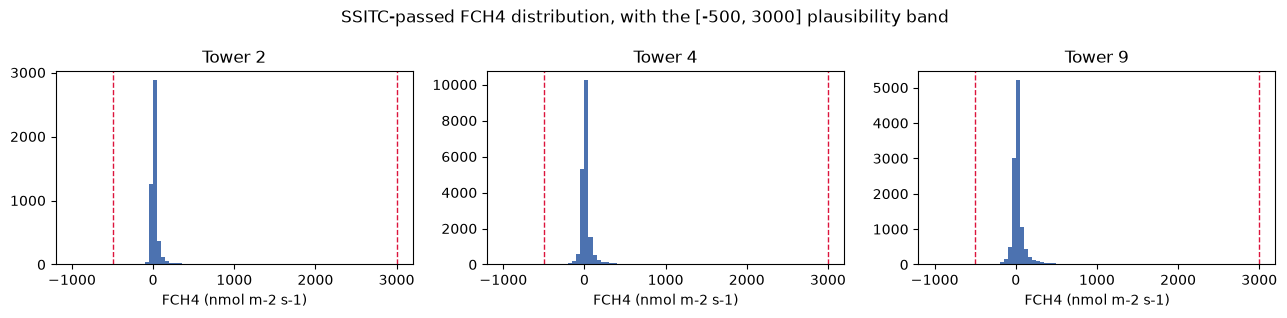

In [5]:
PLAUS_LOW, PLAUS_HIGH = -500, 3000   # nmol m-2 s-1 plausibility bound for FCH4 (D-13)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, t in zip(axes, TOWERS):
    tgt, ssitc = f"FCH4_1_1_1 [Tower {t}]", f"FCH4_SSITC_TEST_1_1_1 [Tower {t}]"
    qc = raw[tgt].where(raw[ssitc].isin([0, 1]))
    n_extreme = int((qc.notna() & ~qc.between(PLAUS_LOW, PLAUS_HIGH)).sum())
    print(f"Tower {t}: SSITC-passed range [{qc.min():.0f}, {qc.max():.0f}] nmol m-2 s-1, "
          f"{n_extreme} points outside [{PLAUS_LOW}, {PLAUS_HIGH}]")
    ax.hist(qc.clip(-1000, 3000).dropna(), bins=80, color="#4C72B0")
    ax.axvline(PLAUS_LOW, color="crimson", ls="--", lw=1); ax.axvline(PLAUS_HIGH, color="crimson", ls="--", lw=1)
    ax.set_title(f"Tower {t}"); ax.set_xlabel("FCH4 (nmol m-2 s-1)")
plt.suptitle("SSITC-passed FCH4 distribution, with the [-500, 3000] plausibility band")
plt.tight_layout(); plt.show()

**Fix:** an FCH4 plausibility filter `[-500, 3000]` nmol m-2 s-1 (D-13), applied together with the
SSITC `{0,1}` filter, defines "target" throughout. Mirrors FC's `[-100, 100]` bound (D-25).

### 1.5 Spatial alignment -- Tower N = Catchment N

**Critical rule (D-18): Tower N's model must use only Catchment N's soil data** -- never average
across catchments. Tower 4's catchment column carries a historical suffix, and its on-tower soil
temperature sensor barely has data.

In [6]:
for t in TOWERS:
    cat = CAT[t]
    swc_col = f"Soil Moisture @ 10cm Depth (%) [{cat}]"
    ts_ec_col = f"TS_1_1_1 [Tower {t}]"                          # on-tower EC soil temp sensor
    ts_ext_col = f"Soil Temperature @ 15cm Depth (oC) [{cat}]"   # own-catchment external SMS sensor
    print(f"Tower {t} <-> {cat}")
    print(f"  own-catchment soil moisture (10cm, external): {100*raw[swc_col].notna().mean():5.1f}% coverage")
    print(f"  on-tower EC soil temperature (TS_1_1_1):      {100*raw[ts_ec_col].notna().mean():5.1f}% coverage")
    print(f"  own-catchment soil temperature (external):    {100*raw[ts_ext_col].notna().mean():5.1f}% coverage")

Tower 2 <-> Catchment 2
  own-catchment soil moisture (10cm, external):  71.0% coverage
  on-tower EC soil temperature (TS_1_1_1):        5.2% coverage
  own-catchment soil temperature (external):     75.2% coverage
Tower 4 <-> Catchment 4 After  2013/08/13
  own-catchment soil moisture (10cm, external):  56.5% coverage
  on-tower EC soil temperature (TS_1_1_1):        9.6% coverage
  own-catchment soil temperature (external):     57.3% coverage
Tower 9 <-> Catchment 9
  own-catchment soil moisture (10cm, external):  66.0% coverage
  on-tower EC soil temperature (TS_1_1_1):       71.5% coverage
  own-catchment soil temperature (external):     69.0% coverage


**Fix:** Tower 4's on-tower EC soil temperature is badly undercovered (~10%, D-16). The
**own-catchment external SMS sensor** has far better coverage and is genuinely site-specific, so
it fully replaces the old cross-tower EC proxy (D-35).

### 1.6 Meteorological driver sourcing -- EC tower vs. external Site/SMS network

NWFP runs two independent sensor networks: each EC tower's own suite, and a separate `[Site]`
MET station + per-catchment SMS soil stations. F-08 (D-35) asks whether external, farm-scale
sourcing beats each tower's own (sometimes gappier) sensor for solar radiation, air temperature,
and wind speed.

In [7]:
SITE_SW = "Solar Radiation (W/m2) [Site]"
SITE_TA = "Air Temperature (oC) [Site]"
SITE_WS = "Wind Speed (km/h) [Site]"

for t in TOWERS:
    for ec_col, site_col, label in [(f"SWIN_1_1_1 [Tower {t}]", SITE_SW, "SWIN/solar"),
                                     (f"TA_0_0_1 [Tower {t}]", SITE_TA, "TA/air temp"),
                                     (f"WS_0_0_1 [Tower {t}]", SITE_WS, "WS/wind")]:
        print(f"Tower {t} {label:10s}: EC-tower {100*raw[ec_col].notna().mean():5.1f}%  |  "
              f"Site-external {100*raw[site_col].notna().mean():5.1f}%")

Tower 2 SWIN/solar: EC-tower  52.7%  |  Site-external  99.0%
Tower 2 TA/air temp: EC-tower  67.3%  |  Site-external  99.0%
Tower 2 WS/wind   : EC-tower  72.1%  |  Site-external  94.4%
Tower 4 SWIN/solar: EC-tower  75.4%  |  Site-external  99.0%
Tower 4 TA/air temp: EC-tower  78.4%  |  Site-external  99.0%
Tower 4 WS/wind   : EC-tower  78.4%  |  Site-external  94.4%
Tower 9 SWIN/solar: EC-tower  71.5%  |  Site-external  99.0%
Tower 9 TA/air temp: EC-tower  74.9%  |  Site-external  99.0%
Tower 9 WS/wind   : EC-tower  74.9%  |  Site-external  94.4%


**Fix (D-35):** swap `SWIN_1_1_1`/`TA_0_0_1`/`WS_0_0_1` for every tower to `[Site]` readings (wind
km/h -> m/s), under the same EC column names. F-08 found this accuracy-neutral to mildly positive
(pooled +0.01-0.014 R2, never harmful) -- adopted mainly for the soil-temperature fix above and
robustness. Built in section 2.2.

### 1.7 Sensor contamination -- USTAR and VPD (the D-48 bug)

Found via a user-observed anomaly: a sustained spike in Tower 2's gap-filled FCH4 during a period
with zero real observations, traced (via SHAP) to `USTAR_0_0_1` never having been
plausibility-filtered, so outlier readings dragged the global-mean fallback far from sane values.

In [8]:
# Met-driver plausibility bounds (D-48). Only USTAR and VPD show real outlier contamination
# across all towers (audited); PPFD/WS/SHF were checked and are clean.
MET_PLAUS = {"USTAR_0_0_1": (0.0, 3.0), "VPD_0_0_1": (0.0, 15.0)}

for base, (lo, hi) in MET_PLAUS.items():
    print(f"--- {base} plausibility bound [{lo}, {hi}] ---")
    for t in TOWERS:
        s = raw[f"{base} [Tower {t}]"].astype(float)
        n_bad = int((s.notna() & ~s.between(lo, hi)).sum())
        pct_bad = 100 * n_bad / s.notna().sum() if s.notna().sum() else np.nan
        print(f"  Tower {t}: n={s.notna().sum():6,}  mean={s.mean():7.3f}  median={s.median():7.3f}  "
              f"max={s.max():10.1f}  |  {n_bad} points ({pct_bad:.1f}%) outside bound")

--- USTAR_0_0_1 plausibility bound [0.0, 3.0] ---
  Tower 2: n=50,563  mean=  2.450  median=  0.233  max=    1039.9  |  722 points (1.4%) outside bound
  Tower 4: n=55,012  mean=  3.332  median=  0.222  max=    1408.8  |  914 points (1.7%) outside bound
  Tower 9: n=52,564  mean=  2.886  median=  0.230  max=    1085.1  |  785 points (1.5%) outside bound
--- VPD_0_0_1 plausibility bound [0.0, 15.0] ---
  Tower 2: n=38,700  mean=  5.988  median=  5.841  max=      36.5  |  818 points (2.1%) outside bound
  Tower 4: n=52,936  mean=  8.387  median=  7.048  max=      41.3  |  6677 points (12.6%) outside bound
  Tower 9: n=45,699  mean=  6.431  median=  6.327  max=      37.1  |  824 points (1.8%) outside bound


**Fix (D-48), applied in section 2.3:** (1) `plausibility_filter()` sets out-of-bound raw readings
to `NaN` before gap-filling; (2) the last-resort fallback changes from mean to median (robust to
outliers by construction).

### 1.8 Tower 2's temporal regime shift -- why a year-based train/test split fails

In [9]:
tgt2, ssitc2 = "FCH4_1_1_1 [Tower 2]", "FCH4_SSITC_TEST_1_1_1 [Tower 2]"
qc2 = raw[tgt2].where(raw[ssitc2].isin([0, 1]))
by_year_valid = qc2.notna().groupby(raw.index.year).sum()
by_year_mean = qc2.groupby(raw.index.year).mean()
cattle2 = raw[f"cattle_{CAT[2]}"]
by_year_cattle = cattle2.groupby(raw.index.year).mean()

summary = pd.DataFrame({"n_valid_FCH4": by_year_valid, "mean_FCH4": by_year_mean.round(1),
                         "mean_cattle_head": by_year_cattle.round(1)})
print("Tower 2 (Catchment 2) by year:")
print(summary.loc[summary["n_valid_FCH4"] > 0].to_string())

Tower 2 (Catchment 2) by year:
          n_valid_FCH4  mean_FCH4  mean_cattle_head
Datetime                                           
2017               314      -24.4               4.5
2018              3644      485.9               5.8
2019               950        1.0               0.0


**Issue (F-07, D-34):** Tower 2's analyser was only live Oct 2017-Jun 2019. 2018 had cattle
(higher FCH4), 2019 had none (near-zero FCH4) -- a genuine regime shift. A year-based train/test
split trains on one regime and tests on the other, guaranteeing a catastrophic result (original
R2 = **-16.9**) that reflects a broken evaluation design, not a bad model.

**Fix (used for every tower, not just Tower 2):** evaluate via **full-period gap-CV** -- synthetic
calendar-shaped gaps cut from each tower's *entire* valid domain (real observations elsewhere
remain available to train on). Implemented in section 4.

### 1.9 FC (CO2 flux) coverage and outliers -- the feature imputed first

In [10]:
FC_LOW, FC_HIGH = -100.0, 100.0   # umol CO2 m-2 s-1 plausibility bound (D-25)

for t in TOWERS:
    fc, ssitc = f"FC_1_1_1 [Tower {t}]", f"FC_SSITC_TEST_1_1_1 [Tower {t}]"
    qc_fc_raw = raw[fc].where(raw[ssitc].isin([0, 1]))
    n_bad = int((qc_fc_raw.notna() & ~qc_fc_raw.between(FC_LOW, FC_HIGH)).sum())
    print(f"Tower {t}: raw {100*raw[fc].notna().mean():5.1f}% valid, "
          f"SSITC-passed {100*qc_fc_raw.notna().mean():5.1f}% valid, "
          f"{n_bad} points outside [{FC_LOW}, {FC_HIGH}] umol m-2 s-1")

Tower 2: raw  61.4% valid, SSITC-passed  44.3% valid, 114 points outside [-100.0, 100.0] umol m-2 s-1
Tower 4: raw  74.3% valid, SSITC-passed  56.3% valid, 125 points outside [-100.0, 100.0] umol m-2 s-1
Tower 9: raw  69.5% valid, SSITC-passed  51.3% valid, 95 points outside [-100.0, 100.0] umol m-2 s-1


**Why FC matters:** an earlier ablation (03b, D-22/D-26) found CO2 flux (FC) is FCH4's single
strongest predictor at NWFP -- adding a gap-filled FCO2 feature flipped Tower 4's RFm from
negative to positive R2. FC itself has real gaps, so it is **reconstructed as a complete feature
before it is used as a CH4-model input** (section 2.1).

### 1.10 EDA summary

| # | Issue | Fix | Where |
|---|---|---|---|
| 1 | FCH4/FC quality flags + implausible extremes | SSITC in {0,1}; FCH4 `[-500,3000]`, FC `[-100,100]` | 2.1, 3.4 |
| 2 | Spatial misalignment risk across 15 catchments | Tower N = Catchment N always (D-18) | 1.5, 3.4 |
| 3 | Tower 4 on-tower soil temperature ~10% coverage | Per-catchment external SMS soil temp (D-35) | 2.2 |
| 4 | USTAR/VPD raw sensor contamination | Plausibility filter + median fallback (D-48) | 2.3 |
| 5 | Tower 2 livestock regime shift | Full-period gap-CV, not year split (D-34) | 4 |
| 6 | FC has real gaps but is FCH4's strongest predictor | RF-reconstructed FCO2 feature | 2.1 |
| 7 | Met drivers previously only mean-imputed | REddyProc-style gap-fill pipeline | 2.3 |

## 2. Feature imputation

Before the FCH4 target is ever touched, two upstream features must be made complete: **FC (CO2
flux)**, reconstructed EC-sourced via a met-driven RF (2.1), and the **meteorological drivers**,
gap-filled REddyProc-style (2.3) on top of the **external-sourced** driver set (2.2).

### 2.1 FCO2 (CO2 flux) reconstruction

FC is kept **EC-sourced** throughout (no external-network twin, unlike SWIN/TA/WS/soil
temperature). A per-tower Random Forest trained on met drivers only (`driver_m`, identical to the
R-02 replication, D-21) reconstructs a complete FCO2 series: where a real QC'd observation exists
it is kept, elsewhere the RF reconstruction is used. Produces `FC_gapfilled [Tower N]`, later used
as the `fc` feature in the CH4 model.

In [11]:
# driver_m (met-only) per tower -- identical to R-02 (D-21); Tower 2 uses its only usable years (D-15).
FCO2_AUX = ["_hour_sin", "_hour_cos", "_doy_sin", "_doy_cos"]

FCO2_TOWER_CONFIGS = {
    2: {"fc": "FC_1_1_1 [Tower 2]", "ssitc": "FC_SSITC_TEST_1_1_1 [Tower 2]",
        "driver_m": ["SWIN_1_1_1 [Tower 2]", "TA_0_0_1 [Tower 2]", "VPD_0_0_1 [Tower 2]",
                     "PPFD_1_1_1 [Tower 2]", "USTAR_0_0_1 [Tower 2]", "WS_0_0_1 [Tower 2]",
                     "RN_1_1_1 [Tower 2]", "Precipitation (mm) [Catchment 2]",
                     "TS_1_1_1 [Tower 9]", "Soil Moisture @ 10cm Depth (%) [Catchment 2]",
                     "SHF_1_1_1 [Tower 2]"],
        "train_yrs": [2018], "test_yrs": [2019]},
    4: {"fc": "FC_1_1_1 [Tower 4]", "ssitc": "FC_SSITC_TEST_1_1_1 [Tower 4]",
        "driver_m": [f"SWIN_1_1_1 [Tower 4]", "TA_0_0_1 [Tower 4]", "VPD_0_0_1 [Tower 4]",
                     "PPFD_1_1_1 [Tower 4]", "USTAR_0_0_1 [Tower 4]", "WS_0_0_1 [Tower 4]",
                     "RN_1_1_1 [Tower 4]", f"Precipitation (mm) [{C4}]",
                     "TS_1_1_1 [Tower 9]", f"Soil Moisture @ 10cm Depth (%) [{C4}]",
                     "SHF_1_1_1 [Tower 4]"],
        "train_yrs": list(range(2018, 2022)), "test_yrs": list(range(2022, 2024))},
    9: {"fc": "FC_1_1_1 [Tower 9]", "ssitc": "FC_SSITC_TEST_1_1_1 [Tower 9]",
        "driver_m": ["SWIN_1_1_1 [Tower 9]", "TA_0_0_1 [Tower 9]", "VPD_0_0_1 [Tower 9]",
                     "PPFD_1_1_1 [Tower 9]", "USTAR_0_0_1 [Tower 9]", "WS_0_0_1 [Tower 9]",
                     "RN_1_1_1 [Tower 9]", "Precipitation (mm) [Catchment 9]",
                     "TS_1_1_1 [Tower 9]", "Soil Moisture @ 10cm Depth (%) [Catchment 9]",
                     "SHF_1_1_1 [Tower 9]"],
        "train_yrs": list(range(2018, 2022)), "test_yrs": list(range(2022, 2024))},
}


@timeit
def add_cyclical(df):
    hour, doy = df.index.hour, df.index.dayofyear
    df["_hour_sin"] = np.sin(2 * np.pi * hour / 24)
    df["_hour_cos"] = np.cos(2 * np.pi * hour / 24)
    df["_doy_sin"] = np.sin(2 * np.pi * doy / 365)
    df["_doy_cos"] = np.cos(2 * np.pi * doy / 365)


@timeit
def reconstruct_fc(df, tower, cfg):
    """RF-reconstruct a complete FC series for one tower; return (fc_gapfilled, stats)."""
    fc_col, ssitc_col, feats = cfg["fc"], cfg["ssitc"], cfg["driver_m"] + FCO2_AUX

    fc_obs = df[fc_col].copy()
    fc_obs[~df[ssitc_col].isin([0, 1])] = np.nan
    fc_obs[fc_obs.notna() & ~fc_obs.between(FC_LOW, FC_HIGH)] = np.nan

    train_mask = df.index.year.isin(cfg["train_yrs"]) & fc_obs.notna()
    imputer = SimpleImputer(strategy="mean")
    X_train = imputer.fit_transform(df.loc[train_mask, feats].values)
    y_train = fc_obs.loc[train_mask].values

    rf = RandomForestRegressor(n_estimators=500, min_samples_leaf=5, n_jobs=1, random_state=42)
    # n_jobs=1, not -1: parallel RF training is NOT bit-reproducible across separate process
    # runs even with random_state fixed (confirmed empirically) -- FCO2 is the one RF step not
    # itself cached, so its cross-run drift would otherwise cascade into every downstream
    # cache key (via the "fc" feature) and silently defeat the section 4.1 model cache.
    rf.fit(X_train, y_train)

    X_all = imputer.transform(df[feats].values)
    fc_recon = pd.Series(rf.predict(X_all), index=df.index)

    fc_gapfilled = fc_obs.copy()
    fc_gapfilled[fc_gapfilled.isna()] = fc_recon[fc_gapfilled.isna()]

    test_mask = df.index.year.isin(cfg["test_yrs"]) & fc_obs.notna()
    if test_mask.sum() >= 20:
        val_r2 = r2_score(fc_obs.loc[test_mask].values, fc_recon.loc[test_mask].values)
    else:
        val_r2 = np.nan
    stats = {"tower": tower, "n_train": int(train_mask.sum()),
              "n_filled_by_recon": int(fc_obs.isna().sum()), "recon_test_r2": val_r2,
              "recon_test_n": int(test_mask.sum())}
    return fc_gapfilled, stats


add_cyclical(raw)
fco2_gapfilled = pd.DataFrame(index=raw.index)
fco2_stats = []
for t in TOWERS:
    filled, stats = reconstruct_fc(raw, t, FCO2_TOWER_CONFIGS[t])
    fco2_gapfilled[f"FC_gapfilled [Tower {t}]"] = filled
    fco2_stats.append(stats)
    print(f"Tower {t}: n_train={stats['n_train']:,}  filled-by-reconstruction={stats['n_filled_by_recon']:,}  "
          f"recon test R2={stats['recon_test_r2']:.3f} (n={stats['recon_test_n']:,})")

Tower 2: n_train=5,511  filled-by-reconstruction=39,159  recon test R2=0.197 (n=1,189)


Tower 4: n_train=21,869  filled-by-reconstruction=30,799  recon test R2=0.745 (n=10,986)


Tower 9: n_train=19,952  filled-by-reconstruction=34,249  recon test R2=0.746 (n=9,592)


### 2.2 External sensor sourcing (F-08, D-35)

Overwrites each tower's `SWIN_1_1_1`/`TA_0_0_1`/`WS_0_0_1` with the `[Site]` external readings
(wind km/h -> m/s), under the same EC column names. Soil temperature is handled in 2.3 by
pointing the driver map at the per-catchment external sensor. FC/VPD/PPFD/RN/USTAR/SHF stay
EC-sourced. Produces `df_ext`, the working dataframe for every remaining step.

In [12]:
df_ext = raw.copy()
for t in TOWERS:
    for ec_col, site_col, conv in [(f"SWIN_1_1_1 [Tower {t}]", SITE_SW, 1.0),
                                    (f"TA_0_0_1 [Tower {t}]", SITE_TA, 1.0),
                                    (f"WS_0_0_1 [Tower {t}]", SITE_WS, 1.0 / 3.6)]:   # km/h -> m/s
        src = pd.to_numeric(raw[site_col], errors="coerce") * conv
        n_ec, n_ext = raw[ec_col].notna().sum(), src.notna().sum()
        df_ext[ec_col] = src
        print(f"  T{t} {ec_col.split(' [')[0]:12s} <- {site_col:28s}  "
              f"cov {100*n_ec/len(raw):.0f}% -> {100*n_ext/len(raw):.0f}%")

print(f"\ndf_ext shape: {df_ext.shape}")

  T2 SWIN_1_1_1   <- Solar Radiation (W/m2) [Site]  cov 53% -> 99%
  T2 TA_0_0_1     <- Air Temperature (oC) [Site]   cov 67% -> 99%
  T2 WS_0_0_1     <- Wind Speed (km/h) [Site]      cov 72% -> 94%
  T4 SWIN_1_1_1   <- Solar Radiation (W/m2) [Site]  cov 75% -> 99%
  T4 TA_0_0_1     <- Air Temperature (oC) [Site]   cov 78% -> 99%
  T4 WS_0_0_1     <- Wind Speed (km/h) [Site]      cov 78% -> 94%
  T9 SWIN_1_1_1   <- Solar Radiation (W/m2) [Site]  cov 71% -> 99%
  T9 TA_0_0_1     <- Air Temperature (oC) [Site]   cov 75% -> 99%
  T9 WS_0_0_1     <- Wind Speed (km/h) [Site]      cov 75% -> 94%

df_ext shape: (70153, 453)


### 2.3 Meteorological driver gap-filling (REddyProc-style, D-33/D-48)

A from-scratch REddyProc-style pipeline: linear interpolation for short gaps, then a
mean-diurnal-course (MDC) with an expanding lookback window for longer ones, then a robust
(median, not mean -- D-48) fallback for total blackouts. `plausibility_filter` runs before
gap-filling so contaminated USTAR/VPD readings never reach the fallback.

`LONG_INTERP_VARS` extends the interpolation limit to 288h for soil moisture/temperature, air
temperature, VPD, and wind speed -- these are smooth, weakly-diurnal signals where plain
interpolation beats MDC on long gaps (found empirically; validated below in 2.4). Radiation-driven
variables (SWIN/PPFD/RN) and SHF keep the original MDC-first behaviour, since a straight line
across a multi-day gap misses their day/night cycle entirely.

In [13]:
@timeit
def plausibility_filter(s, colname):
    """Set values outside MET_PLAUS[colname] to NaN before gap-filling (D-48). No-op if
    colname has no bound registered. Applied ahead of mdc_gapfill so contaminated raw
    outliers never enter the interpolation/MDC/fallback chain in the first place."""
    base = colname.split(" [")[0]
    if base not in MET_PLAUS:
        return s
    lo, hi = MET_PLAUS[base]
    s = s.astype(float).copy()
    s[s.notna() & ~s.between(lo, hi, inclusive="both")] = np.nan
    return s


# Variables where mdc_gapfill's per-hour-of-day pivot averaging is a poor fit: smooth,
# slowly-drifting signals with weak diurnal structure. Plain linear interpolation beats the
# MDC pipeline on long (288h/12-day) gaps for these, consistently across all 3 towers (validated
# in section 2.4). The reverse holds for radiation-driven variables (SWIN/PPFD/RN) and SHF/WS/
# precip, where a straight line across a multi-day gap misses the day/night cycle entirely.
# USTAR is a wash either way and is also left unchanged.
LONG_INTERP_VARS = {"TA_0_0_1", "VPD_0_0_1", "Soil Moisture @ 10cm Depth (%)",
                     "Soil Temperature @ 15cm Depth (oC)", "WS_0_0_1"}


@timeit
def mdc_gapfill(s, colname=None, fallback="median"):
    """Linear interp (<=2h, or <=288h for LONG_INTERP_VARS) then mean-diurnal-course with
    expanding +/-7/14/28/60d window, then a per-hour and finally a global fallback (median by
    default, D-48; mean pre-fix)."""
    out = s.astype(float).copy()
    n_obs = out.notna().sum()
    interp_limit = 288 if (colname is not None and colname.split(" [")[0] in LONG_INTERP_VARS) else 2
    out = out.interpolate(limit=interp_limit, limit_area="inside")
    idx = out.index
    piv = (pd.DataFrame({"v": out.values, "hour": idx.hour, "date": idx.normalize()})
           .pivot_table(index="date", columns="hour", values="v"))
    for w in [7, 14, 28, 60]:
        piv = piv.fillna(piv.rolling(2 * w + 1, min_periods=1, center=True).mean())
    ser = piv.stack(dropna=False)
    key = pd.MultiIndex.from_arrays([idx.normalize(), idx.hour])
    mapped = pd.Series(ser.reindex(key).values, index=idx)
    out = out.where(out.notna(), mapped)
    if out.isna().any():
        agg = "median" if fallback == "median" else "mean"
        hourly_fb = out.groupby(idx.hour).transform(agg)
        out = out.where(out.notna(), hourly_fb)
        out = out.fillna(out.median() if fallback == "median" else out.mean())
    return out, int(n_obs), int(out.notna().sum())


print("plausibility_filter / mdc_gapfill defined.")

plausibility_filter / mdc_gapfill defined.


Applied per driver, per tower: solar, air temp, VPD, PPFD, net radiation, wind, u*, soil heat
flux, precipitation, soil moisture (SWIN/TA/WS hold the external Site values after section 2.2's
swap), and soil temperature -- pointed at the **per-catchment external sensor** (`ts_col_for`),
not the old Tower-9 EC proxy.

In [14]:
@timeit
def ts_col_for(t):
    """Own-catchment external soil temperature (D-35), replacing the old Tower-9 EC proxy (D-16)."""
    return f"Soil Temperature @ 15cm Depth (oC) [{CAT[t]}]"


@timeit
def driver_map(t):
    cat = CAT[t]
    return {"sw": f"SWIN_1_1_1 [Tower {t}]", "ta": f"TA_0_0_1 [Tower {t}]",
            "vpd": f"VPD_0_0_1 [Tower {t}]", "ppfd": f"PPFD_1_1_1 [Tower {t}]",
            "rn": f"RN_1_1_1 [Tower {t}]", "ws": f"WS_0_0_1 [Tower {t}]",
            "ustar": f"USTAR_0_0_1 [Tower {t}]", "shf": f"SHF_1_1_1 [Tower {t}]",
            "precip": f"Precipitation (mm) [{cat}]",
            "swc": f"Soil Moisture @ 10cm Depth (%) [{cat}]", "ts": ts_col_for(t)}


met_filled = pd.DataFrame(index=df_ext.index)
for t in TOWERS:
    print(f"=== Tower {t} ===")
    for k, col in driver_map(t).items():
        filled, n0, n1 = mdc_gapfill(plausibility_filter(df_ext[col], col), colname=col)
        met_filled[f"{col}__f"] = filled.round(4)
        print(f"  {k:6s}: {100*df_ext[col].notna().mean():5.1f}% -> {100*filled.notna().mean():5.1f}%  [{col}]")

=== Tower 2 ===


  sw    :  99.0% -> 100.0%  [SWIN_1_1_1 [Tower 2]]
  ta    :  99.0% -> 100.0%  [TA_0_0_1 [Tower 2]]
  vpd   :  55.2% -> 100.0%  [VPD_0_0_1 [Tower 2]]
  ppfd  :  53.4% -> 100.0%  [PPFD_1_1_1 [Tower 2]]
  rn    :  52.7% -> 100.0%  [RN_1_1_1 [Tower 2]]


  ws    :  94.4% -> 100.0%  [WS_0_0_1 [Tower 2]]


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the 

  ustar :  72.1% -> 100.0%  [USTAR_0_0_1 [Tower 2]]


...

  ustar :  74.9% -> 100.0%  [USTAR_0_0_1 [Tower 9]]


  shf   :  71.5% -> 100.0%  [SHF_1_1_1 [Tower 9]]


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the 

  precip:  54.6% -> 100.0%  [Precipitation (mm) [Catchment 9]]
  swc   :  66.0% -> 100.0%  [Soil Moisture @ 10cm Depth (%) [Catchment 9]]
  ts    :  69.0% -> 100.0%  [Soil Temperature @ 15cm Depth (oC) [Catchment 9]]


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)


### 2.4 Validating the gap-filling accuracy

A shared gap-testing toolkit -- synthetically mask calendar-shaped chunks of a variable's record,
reconstruct them, score against the held-out real values -- defined once here and reused in
section 4's main FCH4 gap-CV harness (which adds a tower-specific `DOMAIN` and the RF/MDS models).

In [15]:
MASK_FRAC = 0.25
SCENARIOS = {"vs": 1, "s": 4, "m": 32, "l": 288, "m1": "mixed"}
N_REPS = 2   # matches F-09a's exact scope, not F-08's original 5

@timeit
def insert_calendar_gaps(df_qc, target, domain_mask, gap_hours, n_reps=N_REPS, seed=0):
    """Randomly place n_reps independent sets of non-overlapping calendar-shaped gaps within the
    domain, each covering ~MASK_FRAC of the domain's valid target points."""
    dom_ts = df_qc.index[domain_mask]; valid = df_qc.loc[domain_mask, target].notna().values
    n = len(dom_ts); target_n = max(1, int(valid.sum() * MASK_FRAC)); rb = np.random.default_rng(seed); reps = []
    for _ in range(n_reps):
        rng = np.random.default_rng(int(rb.integers(0, 2**31))); occ = np.zeros(n, bool); m = 0
        for sp in rng.permutation(n):
            if m >= target_n:
                break
            gh = int(rng.choice([1, 4, 32, 288])) if gap_hours == "mixed" else gap_hours
            ep = min(int(sp) + gh, n)
            if occ[sp:ep].any():
                continue
            occ[sp:ep] = True; m += int(valid[sp:ep].sum())
        reps.append(dom_ts[occ & valid])
    return reps


@timeit
def mets(y, p):
    y = np.asarray(y, float); p = np.asarray(p, float)
    r2 = r2_score(y, p) if np.var(y) > 0 else np.nan
    return r2, float(np.sqrt(np.mean((p - y) ** 2))), float(np.mean(np.abs(p - y))), float(np.mean(p - y))


@timeit
def med_metrics(rows):
    if not rows:
        return {k: np.nan for k in ["R2", "RMSE", "MAE", "MBE"]}
    a = np.array(rows, float)
    return {"R2": np.nanmedian(a[:, 0]), "RMSE": np.median(a[:, 1]),
            "MAE": np.median(a[:, 2]), "MBE": np.median(a[:, 3])}

print("Shared gap-testing toolkit defined (reused in sections 2.4 and 4).")

Shared gap-testing toolkit defined (reused in sections 2.4 and 4).


Checked against a naive constant-median baseline (per fold, on the same held-out points) for all
11 met/soil drivers x 3 towers -- confirms `mdc_gapfill` beats the simplest possible imputation,
not just that R2 crosses zero (a weak bar for skewed variables like USTAR/precipitation).

In [16]:
@timeit
def eval_driver_gapfill(colname):
    """Full-period gap-CV for one gap-filled driver: mdc_gapfill()'s own reconstruction, AND a
    naive constant-median baseline (median of the remaining real domain values, per fold) scored
    on the exact same held-out points."""
    s_raw = df_ext[colname]
    valid_idx = s_raw.index[s_raw.notna()]
    dm = (s_raw.index >= valid_idx[0]) & (s_raw.index <= valid_idx[-1])
    dfq = pd.DataFrame({colname: s_raw})
    out, out_base = {}, {}
    for sc, gh in SCENARIOS.items():
        rr, rr_base = [], []
        for gt in insert_calendar_gaps(dfq, colname, dm, gh, n_reps=N_REPS):
            if len(gt) < 5:
                continue
            sav = s_raw.loc[gt].copy()
            s_masked = s_raw.copy(); s_masked.loc[gt] = np.nan
            filled, _, _ = mdc_gapfill(plausibility_filter(s_masked, colname), colname=colname)
            rr.append(mets(sav.values, filled.loc[gt].values))
            train_median = s_masked.loc[dm].median()
            rr_base.append(mets(sav.values, np.full(len(gt), train_median)))
        out[sc] = med_metrics(rr)
        out_base[sc] = med_metrics(rr_base)
    return out, out_base


driver_rows = []
for t in TOWERS:
    for var_key, colname in driver_map(t).items():
        scn, scn_base = eval_driver_gapfill(colname)
        ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
        ov_base = {k: np.nanmedian([scn_base[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
        driver_rows.append({"tower": t, "driver": var_key, "column": colname,
                             **{f"{k}_overall": round(ov[k], 3) for k in ov},
                             "R2_median_baseline": round(ov_base["R2"], 3),
                             "beats_median_baseline": ov["R2"] > ov_base["R2"]})
        beats = "beats" if ov["R2"] > ov_base["R2"] else "LOSES TO"
        print(f"Tower {t} {var_key:6s}: mdc_gapfill R2={ov['R2']:+.3f}  vs  median-baseline R2={ov_base['R2']:+.3f}"
              f"  ({beats} the naive median baseline)")

MET_GAPFILL_R2 = pd.DataFrame(driver_rows)
MET_GAPFILL_R2

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the 

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the 

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)


...

Tower 9 swc   : mdc_gapfill R2=+0.998  vs  median-baseline R2=-0.216  (beats the naive median baseline)


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the 

Tower 9 ts    : mdc_gapfill R2=+0.994  vs  median-baseline R2=-0.031  (beats the naive median baseline)


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_70016\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the 

,tower,driver,column,R2_overall,RMSE_overall,MAE_overall,MBE_overall,R2_median_baseline,beats_median_baseline
0,2,sw,SWIN_1_1_1 [Tower 2],0.683,111.618,58.179,-7.052,-0.324,True
1,2,ta,TA_0_0_1 [Tower 2],0.685,2.922,2.129,-0.093,-0.002,True
2,2,vpd,VPD_0_0_1 [Tower 2],0.670,2.476,1.495,-0.140,-0.011,True
3,2,ppfd,PPFD_1_1_1 [Tower 2],0.691,194.701,98.607,-11.144,-0.330,True
4,2,rn,RN_1_1_1 [Tower 2],0.742,69.401,43.974,-1.404,-0.180,True
5,2,ws,WS_0_0_1 [Tower 2],0.459,1.316,0.970,-0.043,-0.025,True
6,2,ustar,USTAR_0_0_1 [Tower 2],-0.007,23.188,2.073,-1.982,-0.007,True
7,2,shf,SHF_1_1_1 [Tower 2],0.560,12.289,8.644,0.090,-0.004,True
8,2,precip,Precipitation (mm) [Catchment 2],-0.066,0.107,0.027,-0.007,-0.055,False
9,2,swc,Soil Moisture @ 10cm Depth (%) [Catchment 2],0.995,0.538,0.189,-0.018,-0.275,True


## 3. Additional feature engineering

Builds the remaining engineered features on top of the imputed drivers: productivity/respiration
(GPP/Reco), management-event recency, livestock stocking density, then assembles everything into
the final per-tower modelling frame.

### 3.1 u*-filtering + nighttime NEE partitioning (GPP/Reco)

Two REddyProc-style derived features: a pragmatic binned-plateau **u* threshold** (simplification
of Papale 2006's Moving Point Test, used only to flag data quality) and **NEE partitioning**
(Reichstein 2005 nighttime method: global E0 + block-wise Rref via Lloyd & Taylor 1994 on
nighttime FC, extrapolated to get Reco, with GPP = Reco - FC). GPP was found (F-06, D-33) to be
the single biggest post-pooling accuracy gain in the gap-filling programme (Tower 9 R2 +0.335).

In [17]:
@timeit
def qc_fc(df, t):
    fc = df[f"FC_1_1_1 [Tower {t}]"].astype(float).copy()
    ss = f"FC_SSITC_TEST_1_1_1 [Tower {t}]"
    fc[~df[ss].isin([0, 1])] = np.nan
    fc[fc.notna() & ~fc.between(FC_LOW, FC_HIGH)] = np.nan
    return fc


@timeit
def ustar_threshold(ta, ustar, fc, rg):
    """Binned-plateau u* threshold (pragmatic; simplification of Papale 2006 MPT)."""
    night = (rg < 20) & ta.notna() & ustar.notna() & fc.notna()
    d = pd.DataFrame({"ta": ta[night], "ustar": ustar[night], "fc": fc[night]})
    d = d[d["ustar"] > 0]
    if len(d) < 200:
        return 0.10
    try:
        d["tc"] = pd.qcut(d["ta"], 6, duplicates="drop")
    except ValueError:
        d["tc"] = 0
    thr = []
    for _, g in d.groupby("tc", observed=True):
        if len(g) < 50:
            continue
        edges = np.unique(np.quantile(g["ustar"], np.linspace(0, 1, 21)))
        if len(edges) < 6:
            continue
        g = g.assign(ub=pd.cut(g["ustar"], edges, labels=False, include_lowest=True))
        m = g.groupby("ub")["fc"].mean()
        c = g.groupby("ub")["ustar"].mean()
        if len(m) < 6:
            continue
        plateau = m.loc[m.index >= m.index.max() // 2].mean()
        if not np.isfinite(plateau) or plateau <= 0:
            continue
        ok = m[m >= 0.95 * plateau]
        if len(ok):
            thr.append(float(c.loc[ok.index[0]]))
    if not thr:
        return 0.10
    return float(np.clip(np.median(thr), 0.01, 0.5))


@timeit
def lloyd_taylor(t_k, rref, e0):
    T0, Tref = 227.13, 283.15
    return rref * np.exp(e0 * (1.0 / (Tref - T0) - 1.0 / (t_k - T0)))


@timeit
def partition_nee(fc, ta, rg):
    """Nighttime partitioning: global E0 + block-wise Rref (Lloyd-Taylor) -> GPP, Reco."""
    t_k = ta + 273.15
    night = (rg < 20) & fc.notna() & ta.notna() & (t_k > 230)
    gpp = pd.Series(np.nan, index=fc.index)
    reco = pd.Series(np.nan, index=fc.index)
    if night.sum() < 300:
        return gpp, reco, None
    Tn, Fn = t_k[night].values, fc[night].values
    try:
        (rref0, e0), _ = curve_fit(lloyd_taylor, Tn, Fn, p0=[2.0, 150.0],
                                    bounds=([0, 30], [60, 450]), maxfev=10000)
    except Exception:
        return gpp, reco, None
    days = (fc.index - fc.index[0]).days
    blk = days // 7
    rref_by_blk = {}
    nb = pd.DataFrame({"t_k": t_k[night], "fc": fc[night], "blk": blk[night.values]})
    for b, g in nb.groupby("blk"):
        if len(g) < 8:
            continue
        try:
            (rr,), _ = curve_fit(lambda T, rr: lloyd_taylor(T, rr, e0),
                                  g["t_k"].values, g["fc"].values,
                                  p0=[rref0], bounds=([0], [60]), maxfev=5000)
            rref_by_blk[b] = rr
        except Exception:
            continue
    if not rref_by_blk:
        rref_t = pd.Series(rref0, index=fc.index)
    else:
        blk_series = pd.Series(blk, index=fc.index)
        rref_t = blk_series.map(rref_by_blk).astype(float)
        rref_t = rref_t.interpolate().bfill().ffill().fillna(rref0)
    reco_vals = lloyd_taylor(t_k, rref_t.values, e0)
    reco = pd.Series(reco_vals, index=fc.index)
    gpp = reco - fc
    gpp[gpp < 0] = 0.0
    gpp[rg < 20] = 0.0
    return gpp, reco, float(e0)


gpp_reco = pd.DataFrame(index=df_ext.index)
for t in TOWERS:
    dm = driver_map(t)
    fc = qc_fc(df_ext, t)
    sw = met_filled[f"{dm['sw']}__f"]; ta = met_filled[f"{dm['ta']}__f"]; us = met_filled[f"{dm['ustar']}__f"]
    thr = ustar_threshold(ta, us, fc, sw)
    gpp, reco, e0 = partition_nee(fc, ta, sw)
    gpp_reco[f"GPP [Tower {t}]"] = gpp.round(4)
    gpp_reco[f"Reco [Tower {t}]"] = reco.round(4)
    print(f"Tower {t}: u* threshold={thr:.3f} m/s, E0={e0}, GPP coverage={100*gpp.notna().mean():.0f}%")

Tower 2: u* threshold=0.043 m/s, E0=266.26694078253644, GPP coverage=73%


Tower 4: u* threshold=0.102 m/s, E0=314.4487134164382, GPP coverage=80%


Tower 9: u* threshold=0.119 m/s, E0=274.6884066883368, GPP coverage=77%


### 3.2 Management-event recency features (D-27/D-28/D-32)

NWFP's field-event log (fertiliser, manure/FYM, cuts, liming, cultivation) is parsed into an
hourly recency feature per tower's own catchment: `recency(t) = exp(-(days since most recent
qualifying event) / tau)`. An earlier ablation (F-01, D-27/D-28) found the full 12-column
management set overfits and collapses Tower 9's R2; a pruned, own-catchment-only, two-channel set
(**cut**, **manure**) survived (F-02/F-05, D-29/D-32) as a small, non-harmful addition.

In [18]:
TAU = {"manure": 30.0, "cut": 21.0}   # e-folding decay, days (pruned to the two channels the CH4 model uses)

# Field -> catchment map (NWFP_UG_Design_Develop.pdf, Appendix D). Tower N = Catchment N (D-18).
CATCHMENT_FIELDS = {2: {"NW002"}, 4: {"NW005", "NW006"}, 9: {"NW013", "NW039"}}

CUT_OPS = {"Mow", "Rowing up", "Forage harvest", "Trailers (silage)", "Top",
           "Baling (silage)", "Hay turning"}


@timeit
def classify(row):
    app = str(row.get("Application", "")).lower()
    op = str(row.get("Field_Operation", "")).strip()
    if "inorganic fertiliser" in app:
        # Checked (and discarded) before "organic fertiliser": "inorganic fertiliser" contains
        # "organic fertiliser" as a literal substring ("in" + "organic fertiliser"), so this guard
        # must run first or every inorganic-N event gets misclassified as manure.
        return "fertN"
    if "organic fertiliser" in app:
        return "manure"
    if op in CUT_OPS:
        return "cut"
    return None


@timeit
def recency_series(index, event_times, tau):
    idx_ns = index.values.astype("datetime64[ns]")
    if len(event_times) == 0:
        return np.zeros(len(index))
    ev = np.sort(np.array(event_times, dtype="datetime64[ns]"))
    pos = np.searchsorted(ev, idx_ns, side="right") - 1
    rec = np.zeros(len(index))
    valid = pos >= 0
    days = (idx_ns[valid] - ev[pos[valid]]) / np.timedelta64(1, "D")
    rec[valid] = np.exp(-days / tau)
    return rec


fe = pd.read_csv(COMPILED / "Field_Event_Data_Format_1.csv", low_memory=False)
fe["dt"] = pd.to_datetime(fe["Event_Date"], errors="coerce")
fe["channel"] = fe.apply(classify, axis=1)
fe["field"] = fe["Field"].astype(str).str.strip()
fe = fe.dropna(subset=["dt", "channel"])

mgmt = pd.DataFrame(index=df_ext.index)
for t in TOWERS:
    sub = fe[fe["field"].isin(CATCHMENT_FIELDS[t])]
    for ch, tau in TAU.items():
        evs = sub.loc[sub["channel"] == ch, "dt"].tolist()
        mgmt[f"mgmt_t{t}_{ch}_recency"] = np.round(recency_series(df_ext.index, evs, tau), 5)
    print(f"Tower {t}: manure events={len(sub[sub.channel=='manure'])}, cut events={len(sub[sub.channel=='cut'])}")

mgmt.describe().loc[["mean", "max"]]

Tower 2: manure events=4, cut events=17
Tower 4: manure events=10, cut events=43
Tower 9: manure events=9, cut events=36


,mgmt_t2_manure_recency,mgmt_t2_cut_recency,mgmt_t4_manure_recency,mgmt_t4_cut_recency,mgmt_t9_manure_recency,mgmt_t9_cut_recency
mean,0.022485,0.063833,0.044566,0.079695,0.04371,0.081281
max,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000


### 3.3 Livestock stocking density (F-01/F-02, D-27/D-29)

Livestock is the **single strongest FCH4 driver found in this project** (F-01's SHAP ranking,
D-27) -- enteric fermentation is the dominant CH4 source at a grazed grassland site. Raw head
counts are converted to a **Livestock Unit (LSU) density** (LSU/ha, cattle=1.0/sheep=0.1/lamb=
0.05) divided by each tower's own catchment area -- density matters once catchments of *different*
areas are pooled together (D-29).

Tower 2 (Catchment 2, 6.65 ha): mean LSU/ha=0.252, max=4.511, % hours grazed=11.9%
Tower 4 (Catchment 4 After  2013/08/13, 7.75 ha): mean LSU/ha=1.120, max=4.987, % hours grazed=50.0%
Tower 9 (Catchment 9, 7.75 ha): mean LSU/ha=1.163, max=5.652, % hours grazed=61.4%


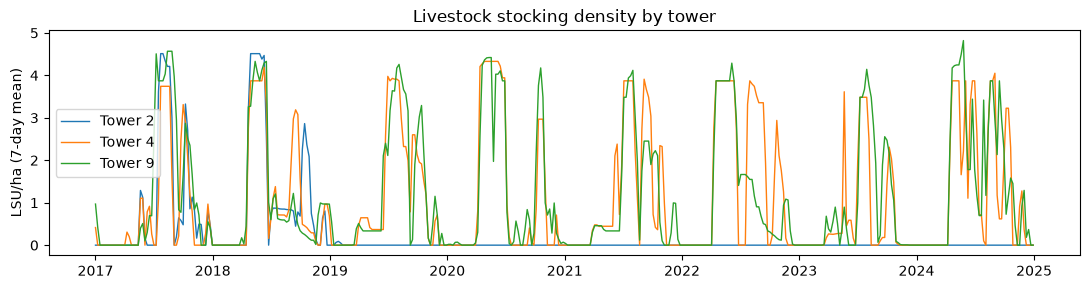

In [19]:
LSU = {"cattle": 1.0, "sheep": 0.1, "lamb": 0.05}

livestock_density = pd.DataFrame(index=df_ext.index)
for t in TOWERS:
    cat = CAT[t]
    lsu = sum(df_ext[f"{s}_{cat}"].fillna(0) * w for s, w in LSU.items())
    livestock_density[f"lsu_dens [Tower {t}]"] = lsu / AREA[t]
    livestock_density[f"graze [Tower {t}]"] = (sum(df_ext[f"{s}_{cat}"].fillna(0) for s in LSU) > 0).astype(float)
    print(f"Tower {t} ({cat}, {AREA[t]} ha): mean LSU/ha={livestock_density[f'lsu_dens [Tower {t}]'].mean():.3f}, "
          f"max={livestock_density[f'lsu_dens [Tower {t}]'].max():.3f}, "
          f"% hours grazed={100*livestock_density[f'graze [Tower {t}]'].mean():.1f}%")

fig, ax = plt.subplots(figsize=(11, 3))
for t in TOWERS:
    ax.plot(livestock_density[f"lsu_dens [Tower {t}]"].resample("7D").mean(), label=f"Tower {t}", lw=1)
ax.set_ylabel("LSU/ha (7-day mean)"); ax.set_title("Livestock stocking density by tower"); ax.legend()
plt.tight_layout(); plt.show()

### 3.4 Final feature frame assembly

Merges every imputed/engineered feature stream (`met_filled`, `fco2_gapfilled`, `mgmt`,
`gpp_reco`) onto the external-sourced base (`df_ext`), then builds a per-tower modelling frame `g`
with: target (FCH4, QC-filtered), the 11 gap-filled met drivers, `fc` (reconstructed FCO2),
cyclical time features, `lsu_dens`/`graze`, soil moisture/temperature lags (168/336/504/672h --
F-04, D-31), pruned management recency, `gpp`/`reco`, and (for the **pooled** model) tower dummies
`is_t2/is_t4/is_t9` -- the "partial pooling" architecture (F-03, D-30) that pools all 3 towers'
training rows while still letting the model tell them apart.

In [20]:
AUX = ["_hs", "_hc", "_ds", "_dc"]
LAG_HOURS = [168, 336, 504, 672]
DUM = ["is_t2", "is_t4", "is_t9"]

d_all = df_ext.join(met_filled).join(fco2_gapfilled).join(mgmt).join(gpp_reco)
for t in TOWERS:
    d_all[f"FC_1_1_1 [Tower {t}]"] = d_all[f"FC_gapfilled [Tower {t}]"]   # FC kept EC-sourced (section 2.1)
print(f"d_all shape: {d_all.shape}")


@timeit
def cfg(t):
    cat = CAT[t]
    met = [f"SWIN_1_1_1 [Tower {t}]", f"TA_0_0_1 [Tower {t}]", f"VPD_0_0_1 [Tower {t}]",
           f"PPFD_1_1_1 [Tower {t}]", f"RN_1_1_1 [Tower {t}]", f"WS_0_0_1 [Tower {t}]",
           f"USTAR_0_0_1 [Tower {t}]", f"SHF_1_1_1 [Tower {t}]",
           f"Precipitation (mm) [{cat}]", ts_col_for(t), f"Soil Moisture @ 10cm Depth (%) [{cat}]"]
    return dict(t=t, cat=cat, area=AREA[t], tgt=f"FCH4_1_1_1 [Tower {t}]",
                ssitc=f"FCH4_SSITC_TEST_1_1_1 [Tower {t}]", met=met,
                fc=f"FC_1_1_1 [Tower {t}]", gpp=f"GPP [Tower {t}]", reco=f"Reco [Tower {t}]",
                swc=f"Soil Moisture @ 10cm Depth (%) [{cat}]", ts=ts_col_for(t),
                mc=f"mgmt_t{t}_cut_recency", mm=f"mgmt_t{t}_manure_recency")


@timeit
def feat_list():
    c = cfg(2)
    return ([m.split(" [")[0] for m in c["met"]] + ["fc"] + AUX + ["lsu_dens", "graze"]
            + [f"swc_l{l}" for l in LAG_HOURS] + [f"ts_l{l}" for l in LAG_HOURS]
            + ["mgmt_cut", "mgmt_manure", "gpp", "reco"])


@timeit
def frame(t, pooled, d):
    """Per-tower FCH4 gap-filling feature frame (target + all imputed/engineered features)."""
    c = cfg(t); d = d.copy(); tgt = c["tgt"]
    d.loc[~d[c["ssitc"]].isin([0, 1]), tgt] = np.nan
    d.loc[d[tgt].notna() & ~d[tgt].between(PLAUS_LOW, PLAUS_HIGH, inclusive="both"), tgt] = np.nan
    h, doy = d.index.hour, d.index.dayofyear
    d["_hs"] = np.sin(2 * np.pi * h / 24); d["_hc"] = np.cos(2 * np.pi * h / 24)
    d["_ds"] = np.sin(2 * np.pi * doy / 365); d["_dc"] = np.cos(2 * np.pi * doy / 365)
    g = pd.DataFrame(index=d.index); g["target"] = d[tgt]
    for k in c["met"]:
        nm = k.split(" [")[0]
        g[nm] = d[k + "__f"] if (k + "__f") in d.columns else d[k]
    g["fc"] = d[c["fc"]]
    for a in AUX:
        g[a] = d[a]
    g["lsu_dens"] = livestock_density[f"lsu_dens [Tower {t}]"]
    g["graze"] = livestock_density[f"graze [Tower {t}]"]
    swc = d[c["swc"] + "__f"] if (c["swc"] + "__f") in d.columns else d[c["swc"]]
    ts = d[c["ts"] + "__f"] if (c["ts"] + "__f") in d.columns else d[c["ts"]]
    for lag in LAG_HOURS:
        g[f"swc_l{lag}"] = swc.shift(lag); g[f"ts_l{lag}"] = ts.shift(lag)
    g["mgmt_cut"] = d[c["mc"]]; g["mgmt_manure"] = d[c["mm"]]
    g["gpp"] = d[c["gpp"]]; g["reco"] = d[c["reco"]]
    if pooled:
        for tt in TOWERS:
            g[f"is_t{tt}"] = 1.0 if tt == t else 0.0
    g["_y"] = d.index.year
    return g


FEATURES = feat_list()
print(f"{len(FEATURES)} base features (+3 tower dummies when pooled): {FEATURES}")

g4_preview = frame(4, pooled=True, d=d_all)
print(f"\nTower 4 frame shape: {g4_preview.shape}, target valid: {g4_preview['target'].notna().sum():,}")
g4_preview[["target", "fc", "lsu_dens", "gpp", "reco", "is_t2", "is_t4", "is_t9"]].dropna(subset=["target"]).head()

d_all shape: (70153, 501)
30 base features (+3 tower dummies when pooled): ['SWIN_1_1_1', 'TA_0_0_1', 'VPD_0_0_1', 'PPFD_1_1_1', 'RN_1_1_1', 'WS_0_0_1', 'USTAR_0_0_1', 'SHF_1_1_1', 'Precipitation (mm)', 'Soil Temperature @ 15cm Depth (oC)', 'Soil Moisture @ 10cm Depth (%)', 'fc', '_hs', '_hc', '_ds', '_dc', 'lsu_dens', 'graze', 'swc_l168', 'swc_l336', 'swc_l504', 'swc_l672', 'ts_l168', 'ts_l336', 'ts_l504', 'ts_l672', 'mgmt_cut', 'mgmt_manure', 'gpp', 'reco']

Tower 4 frame shape: (70153, 35), target valid: 19,469


,target,fc,lsu_dens,gpp,reco,is_t2,is_t4,is_t9
Datetime,,,,,,,,
2017-10-06 16:00:00,5.909675,-3.639656,3.283871,10.4378,6.7981,0.0,1.0,0.0
2017-10-06 20:00:00,7.442396,4.360241,3.283871,0.0000,4.8790,0.0,1.0,0.0
2017-10-06 21:00:00,5.488019,5.381502,3.283871,0.0000,5.4334,0.0,1.0,0.0
2017-10-06 22:00:00,7.009990,5.654010,3.283871,0.0000,5.8139,0.0,1.0,0.0
2017-10-06 23:00:00,2.485738,4.980767,3.283871,0.0000,6.0771,0.0,1.0,0.0


## 4. Gap-filling

This is the harness that produces the target result. As section 1.8 established, the correct way
to evaluate a *gap-filling* (interpolation) model is **not** a train-on-past/test-on-future split
-- it is to synthetically mask chunks of the tower's own real record and see how well the model
recovers them, using every other real observation (before *and* after each synthetic gap) as
training data. Built on the section 2.4 toolkit (`insert_calendar_gaps`, `SCENARIOS`, `N_REPS`,
`mets`, `med_metrics`).

**New here on top of that toolkit:**
- **`DOMAIN`**: each tower's own real analyser-live window (Tower 2 Oct 2017-Jun 2019, Tower 9 Feb
  2020 onward), not the full project span.
- **Models compared**: **MDS** (marginal distribution sampling -- the literature baseline),
  **RFm-solo** (this tower's own data only), **RFm-pooled** (partial pooling -- all 3 towers'
  training rows + tower dummies).
- **Metric**: median R2/RMSE/MAE/MBE across `N_REPS` repetitions, then median again across the 5
  gap-length scenarios for an overall number.

### 4.1 Model caching

Every Random Forest fit in this notebook goes through one shared `fit(feat, trd)` helper, wrapped
to cache each fitted (model, imputer) pair to disk, keyed by an MD5 hash of the exact feature list
+ training rows + target values + hyperparameters -- the key changes automatically if anything
upstream changes, so a stale cache can never silently get reused. Cache lives in `_model_cache/`
(gitignored, same treatment as `data/`); set `USE_CACHE = False` to force a clean re-fit.

In [21]:
import hashlib
import joblib

CACHE_DIR = Path("_model_cache")
CACHE_DIR.mkdir(exist_ok=True)
USE_CACHE = True   # set False to force a clean re-fit of everything, ignoring any cached models

RF_PARAMS = dict(n_estimators=500, min_samples_leaf=5, n_jobs=-1, random_state=42)


@timeit
def _cache_key(feat, trd):
    """MD5 of the exact feature list + training rows + target + RF hyperparameters -- changes
    automatically if any upstream code changes what would be fit, so a stale cache entry can
    never silently get reused for the wrong inputs."""
    h = hashlib.md5()
    h.update("|".join(feat).encode())
    h.update(np.ascontiguousarray(trd[feat].values).tobytes())
    h.update(np.ascontiguousarray(trd["target"].values).tobytes())
    h.update(str(sorted(RF_PARAMS.items())).encode())
    return h.hexdigest()


@timeit
def fit(feat, trd):
    """Fit (or load a cached) RandomForestRegressor + SimpleImputer for this exact
    (feature list, training rows) combination -- the one fitting function used everywhere
    in this notebook's gap-filling sections."""
    key = _cache_key(feat, trd)
    cache_path = CACHE_DIR / f"{key}.joblib"
    if USE_CACHE and cache_path.exists():
        return joblib.load(cache_path)
    imp = SimpleImputer(strategy="mean")
    rf = RandomForestRegressor(**RF_PARAMS)
    rf.fit(imp.fit_transform(trd[feat].values), trd["target"].values)
    if USE_CACHE:
        joblib.dump((rf, imp), cache_path)
    return rf, imp


n_cached = len(list(CACHE_DIR.glob("*.joblib")))
print(f"Model cache: {CACHE_DIR.resolve()}  (USE_CACHE={USE_CACHE}, {n_cached} cached model(s) found)")

Model cache: C:\Users\Nicholas\Documents\COMP0191 MSc Artificial Intelligence for Sustainable Development Project\notebooks\03c_gap_filling_revisited\_model_cache  (USE_CACHE=True, 488 cached model(s) found)


### 4.2 Harness: DOMAIN, MDS baseline, RFm (solo/pooled)

In [22]:
DOMAIN = {2: ("2017-10-01", "2019-06-30"), 4: ("2017-10-01", "2023-12-31"), 9: ("2020-02-01", "2023-12-31")}


@timeit
def dom_mask(idx, t):
    a, b = DOMAIN[t]
    return (idx >= pd.Timestamp(a)) & (idx <= pd.Timestamp(b))


@timeit
def mds_fill_batch(df_obs, target, sw_col, ta_col, gap_ts):
    """Marginal distribution sampling: average real values within an expanding similarity
    window (time-of-day, +/- days, radiation/temperature tolerance), literature baseline."""
    SW_TOL, TA_TOL = 50.0, 2.5
    WINDOWS = [pd.Timedelta(days=d) for d in [7, 14, 28, 91]]
    av = df_obs[df_obs[target].notna()]; ay = av[target].values.astype(float)
    ahr = av.index.hour.to_numpy(); adoy = av.index.dayofyear.to_numpy(); ats = av.index.to_numpy()
    asw = av[sw_col].values.astype(float); ata = av[ta_col].values.astype(float)
    gi = pd.DatetimeIndex(gap_ts)
    gsw = df_obs.reindex(gi)[sw_col].values.astype(float); gta = df_obs.reindex(gi)[ta_col].values.astype(float)
    preds = {}
    for i, t in enumerate(gap_ts):
        tt = np.datetime64(t); hr = t.hour; doy = t.dayofyear; sv = gsw[i]; tv = gta[i]
        day = (not np.isnan(sv)) and sv > 10.0; filled = False
        for wd in WINDOWS:
            w = wd.to_timedelta64()
            m = (ats >= tt - w) & (ats <= tt + w) & (np.abs(ahr - hr) <= 1)
            if not np.isnan(tv):
                m &= (np.abs(ata - tv) <= TA_TOL) | np.isnan(ata)
            if day and not np.isnan(sv):
                m &= (np.abs(asw - sv) <= SW_TOL) | np.isnan(asw)
            c = ay[m]
            if len(c) >= 1:
                preds[t] = float(np.nanmean(c)); filled = True; break
        if not filled:
            sh = np.abs(ahr - hr) <= 1
            dd = np.minimum(np.abs(adoy - doy), 365 - np.abs(adoy - doy))
            c = ay[sh & (dd <= 7)]
            if len(c) >= 1:
                preds[t] = float(np.nanmean(c))
    return preds


print("FCH4-specific harness pieces defined (DOMAIN, dom_mask, mds_fill_batch).")

FCH4-specific harness pieces defined (DOMAIN, dom_mask, mds_fill_batch).


In [23]:
@timeit
def run_mds(t):
    """MDS baseline gap-CV for tower t."""
    d = d_all.copy(); c = cfg(t); tgt = c["tgt"]
    d.loc[~d[c["ssitc"]].isin([0, 1]), tgt] = np.nan
    d.loc[d[tgt].notna() & ~d[tgt].between(PLAUS_LOW, PLAUS_HIGH, inclusive="both"), tgt] = np.nan
    swin_col = f"SWIN_1_1_1 [Tower {t}]"; ta_col = f"TA_0_0_1 [Tower {t}]"
    dm = dom_mask(d.index, t); out = {}
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(d, tgt, dm, gh):
            if len(gt) < 5:
                continue
            sav = d.loc[gt, tgt].copy(); d.loc[gt, tgt] = np.nan
            p = mds_fill_batch(d, tgt, swin_col, ta_col, list(gt)); d.loc[gt, tgt] = sav
            ts_ = [x for x in gt if x in p]
            if len(ts_) >= 5:
                rr.append(mets(sav.loc[ts_].values, np.array([p[x] for x in ts_])))
        out[sc] = med_metrics(rr)
    return out


@timeit
def run_rf(t, pooled):
    """RFm (solo or partial-pooled) gap-CV for tower t."""
    feat = FEATURES + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    frames = {tt: frame(tt, pooled, d_all) for tt in towers}
    g = frames[t]; idx = g.index; out = {}; dm = dom_mask(idx, t)
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(g, "target", dm, gh):
            if len(gt) < 5:
                continue
            base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
            if pooled:
                others = []
                for tt in towers:
                    if tt == t:
                        continue
                    gg = frames[tt]; dmt = dom_mask(gg.index, tt)
                    others.append(gg[dmt & gg["target"].notna().values])
                trd = pd.concat([trd] + others, ignore_index=True)
            rf, imp = fit(feat, trd)
            yp = rf.predict(imp.transform(g.loc[gt, feat].values))
            rr.append(mets(g.loc[gt, "target"].values, yp))
        out[sc] = med_metrics(rr)
    return out


print("run_mds / run_rf defined.")

run_mds / run_rf defined.


### 4.3 Run the full grid

3 towers x {MDS, RFm-solo, RFm-pooled} x 5 gap-length scenarios x `N_REPS` repetitions = 60
separate 500-tree Random Forest fits (plus MDS's windowed-averaging passes). First run populates
`_model_cache/` from scratch (~10-15 min); subsequent runs against the same data are cache hits.

In [24]:
import time
t_start = time.time()

RESU = {}
for t in TOWERS:
    RESU[(t, "MDS")] = run_mds(t)
    print(f"done MDS       Tower {t}  ({time.time()-t_start:6.0f}s elapsed)", flush=True)
    RESU[(t, "RFm_solo")] = run_rf(t, pooled=False)
    print(f"done RFm_solo  Tower {t}  ({time.time()-t_start:6.0f}s elapsed)", flush=True)
    RESU[(t, "RFm_pool")] = run_rf(t, pooled=True)
    print(f"done RFm_pool  Tower {t}  ({time.time()-t_start:6.0f}s elapsed)", flush=True)

print(f"\nALL DONE in {time.time()-t_start:.0f}s")

done MDS       Tower 2  (     1s elapsed)


done RFm_solo  Tower 2  (     2s elapsed)


done RFm_pool  Tower 2  (     6s elapsed)


done MDS       Tower 4  (    10s elapsed)


done RFm_solo  Tower 4  (    12s elapsed)


done RFm_pool  Tower 4  (    16s elapsed)


done MDS       Tower 9  (    18s elapsed)


done RFm_solo  Tower 9  (    20s elapsed)


done RFm_pool  Tower 9  (    23s elapsed)



ALL DONE in 23s


### 4.4 Results

Overall (median-of-medians across the 5 gap scenarios) R2/RMSE/MAE/MBE per tower and model.

In [25]:
rows = []
for (t, model), scn in RESU.items():
    ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
    rows.append({"tower": t, "model": model, **{f"{k}_overall": round(ov[k], 3) for k in ov},
                 **{f"R2_{s}": round(scn[s]["R2"], 3) if pd.notna(scn[s]["R2"]) else np.nan for s in SCENARIOS}})
R = pd.DataFrame(rows)

print("=== Overall median R2/RMSE/MAE/MBE, external-sourced, full-period gap-CV ===")
print(R.set_index(["tower", "model"])[["R2_overall", "RMSE_overall", "MAE_overall", "MBE_overall"]].to_string())

print("\n=== Per-scenario R2 ===")
print(R.set_index(["tower", "model"])[[f"R2_{s}" for s in SCENARIOS]].to_string())

TARGET_R2 = {2: 0.574, 4: 0.402, 9: 0.418}   # BEST_RESULTS.md section 1 (D-35/D-48/D-49)
print("\n=== RFm_pool vs. target result (BEST_RESULTS.md) ===")
for t in TOWERS:
    got = R.loc[(R.tower == t) & (R.model == "RFm_pool"), "R2_overall"].iloc[0]
    print(f"Tower {t}: this notebook R2={got:.3f}  |  BEST_RESULTS.md R2={TARGET_R2[t]:.3f}  "
          f"(diff={got-TARGET_R2[t]:+.3f})")

=== Overall median R2/RMSE/MAE/MBE, external-sourced, full-period gap-CV ===
                R2_overall  RMSE_overall  MAE_overall  MBE_overall
tower model                                                       
2     MDS           -0.167       158.826       51.415        1.478
      RFm_solo       0.398        94.816       35.363        5.896
      RFm_pool       0.576        75.045       31.226        2.791
4     MDS           -0.207       138.494       56.293        0.510
      RFm_solo       0.382        99.602       42.826        2.475
      RFm_pool       0.404       100.275       42.796        3.692
9     MDS           -0.337       155.288       69.295       -1.092
      RFm_solo       0.356       110.867       51.974        2.476
      RFm_pool       0.426       107.099       49.312        0.734

=== Per-scenario R2 ===
                R2_vs   R2_s   R2_m   R2_l  R2_m1
tower model                                      
2     MDS      -0.071 -0.154 -0.167 -2.945 -1.715
      RFm_s

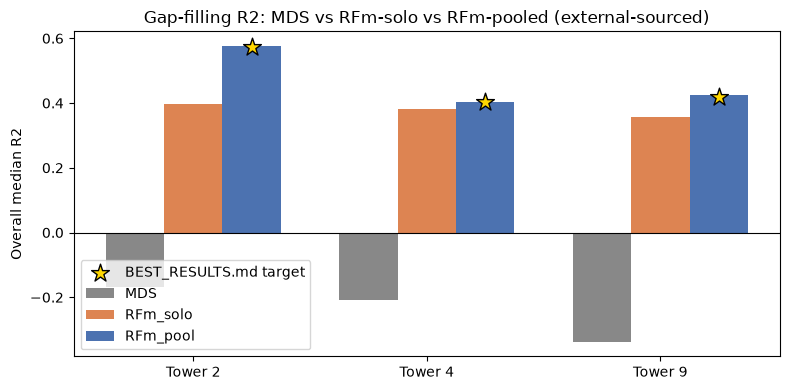

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))
width = 0.25
models = ["MDS", "RFm_solo", "RFm_pool"]
colors = {"MDS": "#888888", "RFm_solo": "#DD8452", "RFm_pool": "#4C72B0"}
xpos = np.arange(len(TOWERS))
for i, m in enumerate(models):
    vals = [R.loc[(R.tower == t) & (R.model == m), "R2_overall"].iloc[0] for t in TOWERS]
    ax.bar(xpos + (i - 1) * width, vals, width, label=m, color=colors[m])
for t in TOWERS:
    ax.scatter(xpos[TOWERS.index(t)] + width, TARGET_R2[t], marker="*", s=180, color="gold",
               edgecolor="black", zorder=5, label="BEST_RESULTS.md target" if t == 2 else None)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(xpos); ax.set_xticklabels([f"Tower {t}" for t in TOWERS])
ax.set_ylabel("Overall median R2"); ax.set_title("Gap-filling R2: MDS vs RFm-solo vs RFm-pooled (external-sourced)")
ax.legend(); plt.tight_layout(); plt.show()

### 4.5 Daily-resolution accuracy (out-of-sample)

Section 4.4's headline R2 is computed at **hourly** resolution. This reuses the exact same
held-out mechanism restricted to the **"l" (288h/12-day) gap scenario** specifically -- a 288h gap
consists of complete calendar days, so daily-averaging the held-out actual/predicted pairs gives a
clean, still-genuinely-out-of-sample daily comparison.

In [27]:
@timeit
def run_rf_capture(t, pooled, gap_hours, n_reps):
    """Like run_rf, but returns the raw (timestamp, actual, predicted) pairs for every
    held-out point across all repetitions, instead of just the aggregated metrics."""
    feat = FEATURES + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    frames = {tt: frame(tt, pooled, d_all) for tt in towers}
    g = frames[t]; dm = dom_mask(g.index, t)
    records = []
    for gt in insert_calendar_gaps(g, "target", dm, gap_hours, n_reps=n_reps):
        if len(gt) < 5:
            continue
        base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
        if pooled:
            others = []
            for tt in towers:
                if tt == t:
                    continue
                gg = frames[tt]; dmt = dom_mask(gg.index, tt)
                others.append(gg[dmt & gg["target"].notna().values])
            trd = pd.concat([trd] + others, ignore_index=True)
        rf, imp = fit(feat, trd)
        yp = rf.predict(imp.transform(g.loc[gt, feat].values))
        records.append(pd.DataFrame({"actual": g.loc[gt, "target"].values, "pred": yp}, index=gt))
    return pd.concat(records) if records else pd.DataFrame(columns=["actual", "pred"])

In [28]:
daily_rows = []
pairs_parts = []
for t in TOWERS:
    pairs = run_rf_capture(t, pooled=True, gap_hours=288, n_reps=N_REPS)
    hourly_r2 = r2_score(pairs["actual"], pairs["pred"])
    daily = pairs.groupby(pairs.index.normalize()).mean()
    daily_r2 = r2_score(daily["actual"], daily["pred"])
    daily_rows.append({"tower": t, "n_held_out_hours": len(pairs), "n_held_out_days": len(daily),
                        "R2_hourly": round(hourly_r2, 3), "R2_daily": round(daily_r2, 3),
                        "delta": round(daily_r2 - hourly_r2, 3)})
    print(f"Tower {t}: {len(pairs):,} held-out hours -> {len(daily):,} days | "
          f"R2 hourly={hourly_r2:.3f}  R2 daily={daily_r2:.3f}  (delta={daily_r2-hourly_r2:+.3f})")
    pairs_parts.append(pairs.assign(tower=t).reset_index().rename(columns={"index": "Datetime"}))

DAILY_R2 = pd.DataFrame(daily_rows).set_index("tower")
HELD_OUT_PAIRS_L = pd.concat(pairs_parts, ignore_index=True)   # raw (out-of-sample) predictions, "l" scenario
DAILY_R2

Tower 2: 2,565 held-out hours -> 224 days | R2 hourly=0.533  R2 daily=0.207  (delta=-0.325)


Tower 4: 9,754 held-out hours -> 860 days | R2 hourly=0.268  R2 daily=0.321  (delta=+0.053)


Tower 9: 5,682 held-out hours -> 490 days | R2 hourly=0.281  R2 daily=0.504  (delta=+0.223)


,n_held_out_hours,n_held_out_days,R2_hourly,R2_daily,delta
tower,,,,,
2,2565,224,0.533,0.207,-0.325
4,9754,860,0.268,0.321,0.053
9,5682,490,0.281,0.504,0.223


### 4.6 Production gap-filled series

Sections 4.3-4.5 measure accuracy via **held-out synthetic gaps** -- that remains the number to
trust. This section is different in kind: fits **one final** partial-pooled RFm on **all**
available real (QC'd) FCH4 data across all 3 towers (no gaps withheld) and predicts a continuous
series per tower -- this is what "gap-filling in production" produces, and the notebook's output
dataframe. Because the model has seen every real point shown below, this is **not** an
out-of-sample accuracy check (compare 4.4/4.5's R2 for that) -- it exists to let you look at what
the gap-filler produces.

In [29]:
frames_prod = {tt: frame(tt, pooled=True, d=d_all) for tt in TOWERS}
trd_prod = pd.concat([frames_prod[tt][dom_mask(frames_prod[tt].index, tt) & frames_prod[tt]["target"].notna().values]
                       for tt in TOWERS], ignore_index=True)
feat_prod = FEATURES + DUM
rf_prod, imp_prod = fit(feat_prod, trd_prod)
print(f"Production model fit on {len(trd_prod):,} real pooled rows (all 3 towers, no gaps withheld).")

series_parts = []
for t in TOWERS:
    g = frames_prod[t]; dm = dom_mask(g.index, t)
    X_all = imp_prod.transform(g.loc[dm, feat_prod].values)
    y_pred = pd.Series(rf_prod.predict(X_all), index=g.index[dm])
    y_obs = g.loc[dm, "target"]
    part = pd.DataFrame({"tower": t, "y_observed": y_obs, "y_gapfilled": y_pred})
    series_parts.append(part)
    print(f"Tower {t}: {len(part):,} hourly rows ({t}'s domain), {y_obs.notna().sum():,} real observations")

FCH4_GAPFILLED = pd.concat(series_parts).reset_index().rename(columns={"index": "Datetime"})
FCH4_GAPFILLED.head()

Production model fit on 35,586 real pooled rows (all 3 towers, no gaps withheld).
Tower 2: 15,289 hourly rows (2's domain), 4,890 real observations


Tower 4: 54,769 hourly rows (4's domain), 19,465 real observations
Tower 9: 34,297 hourly rows (9's domain), 11,231 real observations


,Datetime,tower,y_observed,y_gapfilled
0,2017-10-01 00:00:00,2,NaN,17.973340
1,2017-10-01 01:00:00,2,NaN,17.545792
2,2017-10-01 02:00:00,2,NaN,16.802216
3,2017-10-01 03:00:00,2,NaN,15.068316
4,2017-10-01 04:00:00,2,NaN,15.035892


**Daily mean** is the comparable view across days regardless of how many real hourly observations
happened to fall on that day.

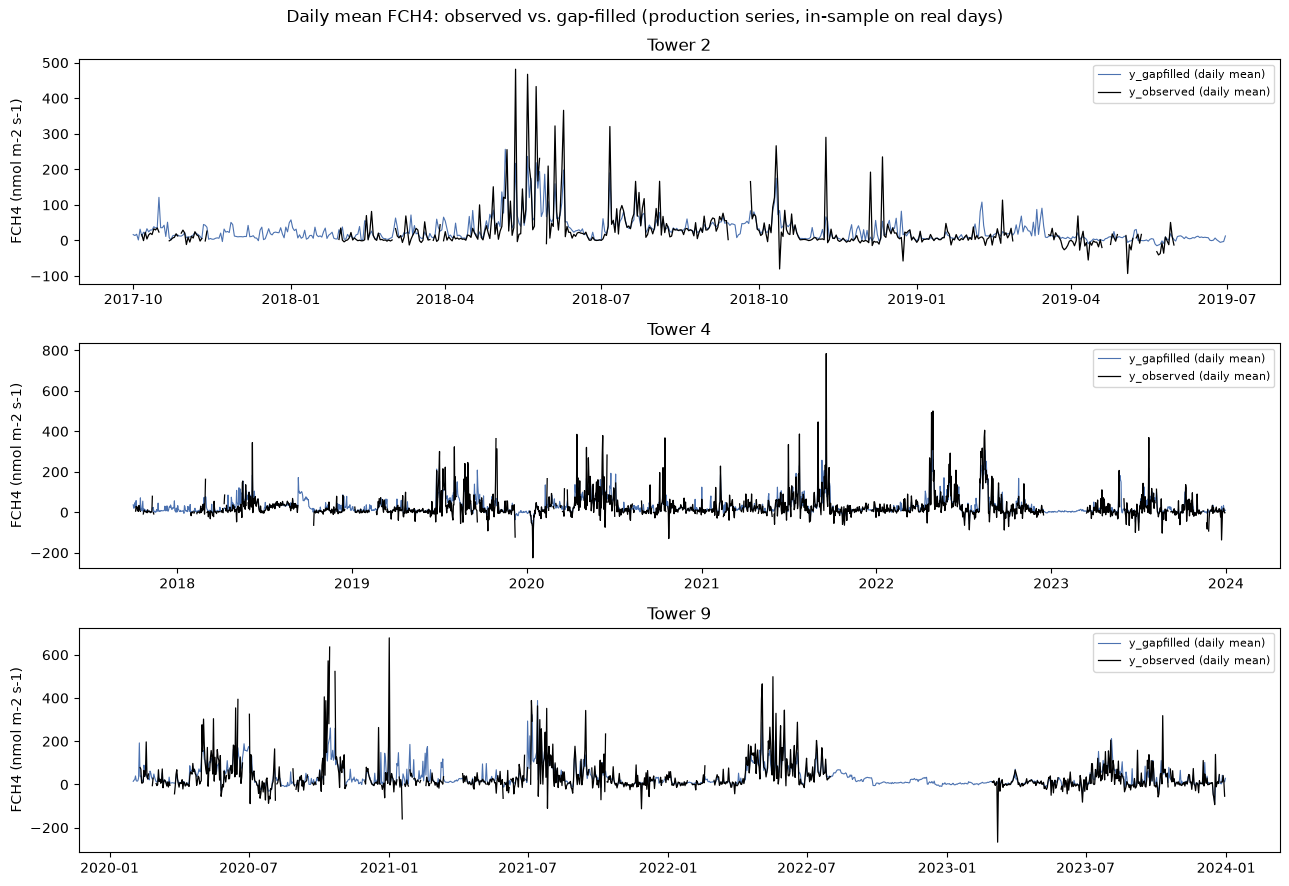

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)
for ax, t in zip(axes, TOWERS):
    sub = FCH4_GAPFILLED[FCH4_GAPFILLED.tower == t].set_index("Datetime")
    daily_obs = sub["y_observed"].resample("D").mean()
    daily_pred = sub["y_gapfilled"].resample("D").mean()
    ax.plot(daily_pred.index, daily_pred.values, color="#4C72B0", lw=0.8, label="y_gapfilled (daily mean)")
    ax.plot(daily_obs.index, daily_obs.values, color="black", lw=0.9, label="y_observed (daily mean)")
    ax.set_title(f"Tower {t}"); ax.set_ylabel("FCH4 (nmol m-2 s-1)"); ax.legend(fontsize=8, loc="upper right")
plt.suptitle("Daily mean FCH4: observed vs. gap-filled (production series, in-sample on real days)")
plt.tight_layout(); plt.show()

**Hourly zoom** -- each tower's own last 90 days of domain, at native hourly resolution (a
full-domain hourly plot is unreadable).

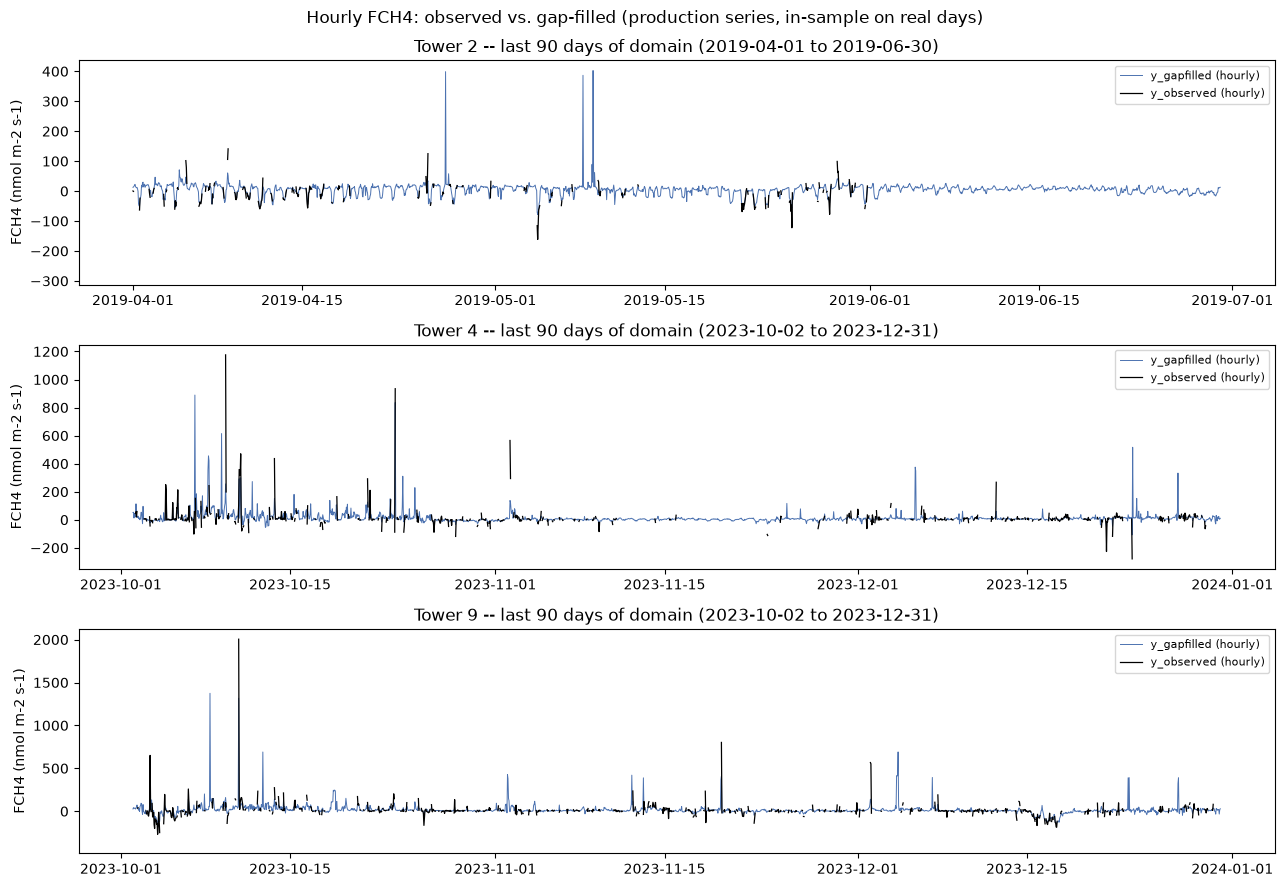

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)
for ax, t in zip(axes, TOWERS):
    sub = FCH4_GAPFILLED[FCH4_GAPFILLED.tower == t].set_index("Datetime")
    window = sub.loc[sub.index.max() - pd.Timedelta(days=90):]
    ax.plot(window.index, window["y_gapfilled"], color="#4C72B0", lw=0.7, label="y_gapfilled (hourly)")
    ax.plot(window.index, window["y_observed"], color="black", lw=0.9, label="y_observed (hourly)")
    ax.set_title(f"Tower {t} -- last 90 days of domain ({window.index.min().date()} to {window.index.max().date()})")
    ax.set_ylabel("FCH4 (nmol m-2 s-1)"); ax.legend(fontsize=8, loc="upper right")
plt.suptitle("Hourly FCH4: observed vs. gap-filled (production series, in-sample on real days)")
plt.tight_layout(); plt.show()

### 4.7 Saving outputs to `_data/`

| File | Contents |
|---|---|
| `fch4_gapfilled.csv` | Full per-tower production series (`y_observed`, `y_gapfilled`), hourly, all 3 towers |
| `feature_frame.csv` | The exact engineered feature matrix fed to the RF, hourly, all 3 towers |
| `gap_cv_results_hourly.csv` | Per-tower/model/scenario hourly R2/RMSE/MAE/MBE from the held-out gap-CV grid |
| `daily_r2_results.csv` | Hourly-vs-daily R2 comparison from the "l"-scenario held-out pairs |
| `held_out_pairs_l_scenario.csv` | The raw, genuinely out-of-sample (timestamp, tower, actual, predicted) pairs |

Not gitignored (unlike `_model_cache/`) -- these are the notebook's actual output artifacts.

In [32]:
DATA_DIR = Path("_data")
DATA_DIR.mkdir(exist_ok=True)

FCH4_GAPFILLED.to_csv(DATA_DIR / "fch4_gapfilled.csv", index=False)
print(f"Saved {DATA_DIR/'fch4_gapfilled.csv'}  ({len(FCH4_GAPFILLED):,} rows)")

feature_rows = []
for t in TOWERS:
    g = frames_prod[t]; dm = dom_mask(g.index, t)
    fg = g.loc[dm, ["target"] + FEATURES].copy()
    fg["tower"] = t
    fg = fg.reset_index().rename(columns={"index": "Datetime"})
    feature_rows.append(fg)
FEATURE_FRAME = pd.concat(feature_rows, ignore_index=True)
FEATURE_FRAME.to_csv(DATA_DIR / "feature_frame.csv", index=False)
print(f"Saved {DATA_DIR/'feature_frame.csv'}  ({len(FEATURE_FRAME):,} rows x {FEATURE_FRAME.shape[1]} cols)")

R.to_csv(DATA_DIR / "gap_cv_results_hourly.csv", index=False)
print(f"Saved {DATA_DIR/'gap_cv_results_hourly.csv'}  ({len(R)} rows)")

DAILY_R2.reset_index().to_csv(DATA_DIR / "daily_r2_results.csv", index=False)
print(f"Saved {DATA_DIR/'daily_r2_results.csv'}  ({len(DAILY_R2)} rows)")

HELD_OUT_PAIRS_L.to_csv(DATA_DIR / "held_out_pairs_l_scenario.csv", index=False)
print(f"Saved {DATA_DIR/'held_out_pairs_l_scenario.csv'}  ({len(HELD_OUT_PAIRS_L):,} rows)")

total_mb = sum(f.stat().st_size for f in DATA_DIR.glob("*.csv")) / 1e6
print(f"\n_data/ total size: {total_mb:.1f} MB")

Saved _data\fch4_gapfilled.csv  (104,355 rows)


Saved _data\feature_frame.csv  (104,355 rows x 33 cols)
Saved _data\gap_cv_results_hourly.csv  (9 rows)
Saved _data\daily_r2_results.csv  (3 rows)
Saved _data\held_out_pairs_l_scenario.csv  (18,001 rows)

_data/ total size: 120.7 MB


## 5. Uncertainty quantification: Area of Applicability

This project already has an established, from-scratch Area-of-Applicability implementation
(`dissimilarity_index()`, `src/models/scenario_hybrid.py`, in the spirit of Meyer & Pebesma 2021)
used for the Phase 07 scenario-analysis UQ work (S-01/S-03/U-03), replicated **inline** here
(cannot be imported, per this notebook's no-`src/`-dependency constraint).

**Mechanics**: for a query point's feature vector, find its nearest neighbour (Euclidean, in
`StandardScaler`-scaled feature space) among the RF's real training rows. A point is flagged
"outside the Area of Applicability" if that distance exceeds `Q3 + 1.5*IQR` of the training data's
*own* leave-one-out nearest-neighbour distances (a Tukey outlier fence) -- i.e., is this point
further from its nearest training neighbour than training points typically are from each other?

Section 5.2 validates the metric against real held-out error *before* section 5.3 applies it as a
reliability flag on the production series.

### 5.1 Definition

In [33]:
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

@timeit
def dissimilarity_index(X_train, X_query):
    """From-scratch Area-of-Applicability metric (Meyer & Pebesma 2021 in spirit), replicated
    inline from src/models/scenario_hybrid.py's dissimilarity_index() for consistency with this
    project's established scenario-analysis UQ convention (S-01/S-03/U-03) -- not a new formula.
    Returns (d_query, threshold, flagged)."""
    scaler = StandardScaler().fit(X_train)
    Xtr = scaler.transform(X_train)
    Xq = scaler.transform(X_query)

    d_query = cdist(Xq, Xtr).min(axis=1)

    d_train_matrix = cdist(Xtr, Xtr)
    np.fill_diagonal(d_train_matrix, np.inf)
    d_train_loo = d_train_matrix.min(axis=1)
    q1, q3 = np.percentile(d_train_loo, [25, 75])
    threshold = q3 + 1.5 * (q3 - q1)

    flagged = d_query > threshold
    return d_query, threshold, flagged

print("dissimilarity_index defined.")

dissimilarity_index defined.


### 5.2 Validation: does the dissimilarity index actually predict held-out error?

Reuses `HELD_OUT_PAIRS_L` (section 4.5 -- genuinely out-of-sample "l"-scenario points, all 3
towers). `X_train` is `trd_prod[FEATURES + DUM]` excluding those held-out timestamps -- comparing
a point against a training set that secretly includes it would give a trivially small distance
everywhere, so the held-out timestamps are excluded here specifically for this validation (section
5.3's production application is correct as-is, since the deployed model genuinely did train on
every real point there).

In [34]:
held_out_by_tower = {t: set(HELD_OUT_PAIRS_L.loc[HELD_OUT_PAIRS_L.tower == t, "Datetime"]) for t in TOWERS}
frames_di = {t: frame(t, pooled=True, d=d_all) for t in TOWERS}
trd_prod_excl = pd.concat([
    frames_di[t][dom_mask(frames_di[t].index, t) & frames_di[t]["target"].notna().values
                  & ~frames_di[t].index.isin(held_out_by_tower[t])]
    for t in TOWERS
], ignore_index=True)
X_train_di = imp_prod.transform(trd_prod_excl[FEATURES + DUM].values)

# Re-derive feature vectors for the held-out "l"-scenario points at their exact timestamps.
query_rows = []
for _, row in HELD_OUT_PAIRS_L.iterrows():
    t = int(row["tower"]); ts = row["Datetime"]
    query_rows.append(frames_di[t].loc[ts, FEATURES + DUM])
X_query_di = imp_prod.transform(pd.DataFrame(query_rows).values)

d_query, di_threshold, flagged = dissimilarity_index(X_train_di, X_query_di)
abs_err = (HELD_OUT_PAIRS_L["pred"] - HELD_OUT_PAIRS_L["actual"]).abs().values

corr_pearson = np.corrcoef(d_query, abs_err)[0, 1]
corr_spearman = pd.Series(d_query).corr(pd.Series(abs_err), method="spearman")
mean_err_flagged = abs_err[flagged].mean() if flagged.any() else np.nan
mean_err_unflagged = abs_err[~flagged].mean() if (~flagged).any() else np.nan

print(f"DI threshold: {di_threshold:.3f}")
print(f"n flagged (outside AOA): {flagged.sum():,} / {len(flagged):,} ({100*flagged.mean():.1f}%)")
print(f"Pearson correlation (DI vs |error|):  {corr_pearson:+.3f}")
print(f"Spearman correlation (DI vs |error|): {corr_spearman:+.3f}")
print(f"Mean |error|, flagged (outside AOA):   {mean_err_flagged:.2f}")
print(f"Mean |error|, unflagged (inside AOA):  {mean_err_unflagged:.2f}")

DI_VALIDATION = pd.DataFrame({"tower": HELD_OUT_PAIRS_L["tower"].values, "Datetime": HELD_OUT_PAIRS_L["Datetime"].values,
                               "actual": HELD_OUT_PAIRS_L["actual"].values, "pred": HELD_OUT_PAIRS_L["pred"].values,
                               "abs_error": abs_err, "dissimilarity_index": d_query, "flagged": flagged})
print("\nPer-tower breakdown:")
for t in TOWERS:
    sub = DI_VALIDATION[DI_VALIDATION.tower == t]
    c_p = np.corrcoef(sub["dissimilarity_index"], sub["abs_error"])[0, 1] if len(sub) > 2 else np.nan
    print(f"  Tower {t}: n={len(sub):,}  Pearson(DI, |err|)={c_p:+.3f}  "
          f"mean|err| flagged={sub.loc[sub.flagged,'abs_error'].mean():.2f}  "
          f"mean|err| unflagged={sub.loc[~sub.flagged,'abs_error'].mean():.2f}")
DI_VALIDATION.head()

DI threshold: 1.950
n flagged (outside AOA): 5,931 / 18,001 (32.9%)
Pearson correlation (DI vs |error|):  +0.110
Spearman correlation (DI vs |error|): +0.145
Mean |error|, flagged (outside AOA):   59.53
Mean |error|, unflagged (inside AOA):  37.87

Per-tower breakdown:
  Tower 2: n=2,565  Pearson(DI, |err|)=+0.123  mean|err| flagged=42.03  mean|err| unflagged=26.92
  Tower 4: n=9,754  Pearson(DI, |err|)=+0.101  mean|err| flagged=60.33  mean|err| unflagged=39.41
  Tower 9: n=5,682  Pearson(DI, |err|)=+0.159  mean|err| flagged=69.45  mean|err| unflagged=38.94


,tower,Datetime,actual,pred,abs_error,dissimilarity_index,flagged
0,2,2017-10-10 15:00:00,4.802356,57.230204,52.427848,3.300174,True
1,2,2017-10-10 22:00:00,21.621562,41.438779,19.817218,3.107869,True
2,2,2017-10-10 23:00:00,13.878446,28.936614,15.058168,2.998854,True
3,2,2017-10-11 00:00:00,44.769662,33.616917,11.152745,2.930529,True
4,2,2017-10-11 01:00:00,54.165464,50.360746,3.804718,2.947896,True


A meaningfully positive correlation and a materially higher flagged-vs-unflagged mean error
support trusting the AOA flag as a genuine reliability signal on top of the point predictions.

### 5.3 Applying the flag to the production gap-filled series

In [35]:
di_prod_parts = []
for t in TOWERS:
    g = frames_prod[t]; dm = dom_mask(g.index, t)
    X_prod = imp_prod.transform(g.loc[dm, FEATURES + DUM].values)
    d_prod, thr_prod, flagged_prod = dissimilarity_index(X_train_di, X_prod)
    sub = FCH4_GAPFILLED[FCH4_GAPFILLED.tower == t].reset_index(drop=True).copy()
    sub["dissimilarity_index"] = d_prod
    sub["outside_aoa"] = flagged_prod
    di_prod_parts.append(sub)
    is_gapfilled = sub["y_observed"].isna()
    n_gapfilled = is_gapfilled.sum()
    n_flagged_of_gapfilled = (sub.loc[is_gapfilled, "outside_aoa"]).sum()
    print(f"Tower {t}: {100*flagged_prod.mean():.1f}% of all hours outside AOA overall; "
          f"of the {n_gapfilled:,} genuinely gap-filled hours, {n_flagged_of_gapfilled:,} "
          f"({100*n_flagged_of_gapfilled/max(n_gapfilled,1):.1f}%) are flagged as lower-trust")

FCH4_GAPFILLED_WITH_UQ = pd.concat(di_prod_parts, ignore_index=True)
FCH4_GAPFILLED_WITH_UQ.to_csv(DATA_DIR / "fch4_gapfilled_with_uq.csv", index=False)
print(f"\nSaved {DATA_DIR/'fch4_gapfilled_with_uq.csv'}  ({len(FCH4_GAPFILLED_WITH_UQ):,} rows)")
FCH4_GAPFILLED_WITH_UQ.head()

Tower 2: 39.5% of all hours outside AOA overall; of the 10,399 genuinely gap-filled hours, 5,038 (48.4%) are flagged as lower-trust


Tower 4: 24.1% of all hours outside AOA overall; of the 35,304 genuinely gap-filled hours, 10,696 (30.3%) are flagged as lower-trust


Tower 9: 29.4% of all hours outside AOA overall; of the 23,066 genuinely gap-filled hours, 8,563 (37.1%) are flagged as lower-trust



Saved _data\fch4_gapfilled_with_uq.csv  (104,355 rows)


,Datetime,tower,y_observed,y_gapfilled,dissimilarity_index,outside_aoa
0,2017-10-01 00:00:00,2,NaN,17.973340,3.276476,True
1,2017-10-01 01:00:00,2,NaN,17.545792,3.199887,True
2,2017-10-01 02:00:00,2,NaN,16.802216,3.126413,True
3,2017-10-01 03:00:00,2,NaN,15.068316,3.022668,True
4,2017-10-01 04:00:00,2,NaN,15.035892,3.075253,True


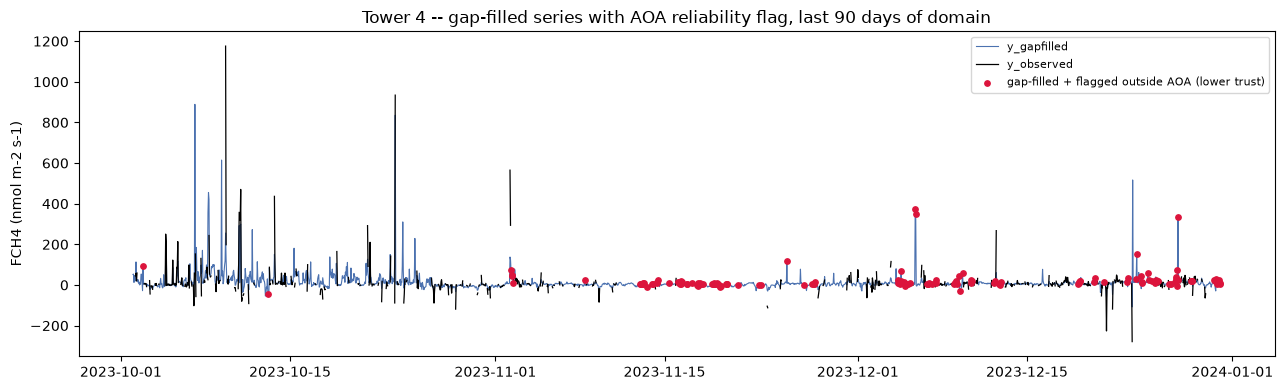

In [36]:
t_demo_uq = 4
sub_uq = FCH4_GAPFILLED_WITH_UQ[FCH4_GAPFILLED_WITH_UQ.tower == t_demo_uq].set_index("Datetime")
window_uq = sub_uq.loc[sub_uq.index.max() - pd.Timedelta(days=90):]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(window_uq.index, window_uq["y_gapfilled"], color="#4C72B0", lw=0.8, label="y_gapfilled")
ax.plot(window_uq.index, window_uq["y_observed"], color="black", lw=0.9, label="y_observed")
flagged_pts = window_uq[window_uq["outside_aoa"] & window_uq["y_observed"].isna()]
ax.scatter(flagged_pts.index, flagged_pts["y_gapfilled"], color="crimson", s=15, zorder=5,
           label="gap-filled + flagged outside AOA (lower trust)")
ax.set_ylabel("FCH4 (nmol m-2 s-1)"); ax.legend(fontsize=8, loc="upper right")
ax.set_title(f"Tower {t_demo_uq} -- gap-filled series with AOA reliability flag, last 90 days of domain")
plt.tight_layout(); plt.show()

`FCH4_GAPFILLED_WITH_UQ` (saved to `_data/fch4_gapfilled_with_uq.csv`) now carries a per-point
`outside_aoa` flag alongside every gap-filled value -- a validated reliability signal, distinct
from and complementary to the conformal-interval UQ this project has elsewhere (U-02/U-03).

---

## Summary

This notebook reproduces, end to end, with zero `src/` dependencies:
1. **EDA** -- 7 data-quality issues, each tied to the fix implemented downstream (section 1).
2. **Feature imputation** -- a complete FCO2 feature via met-driven RF, the external-sourced
   driver variant, and REddyProc-style gap-filling for every meteorological driver, with a
   held-out accuracy check (section 2).
3. **Additional feature engineering** -- GPP/Reco partitioning, pruned management recency,
   livestock stocking density, and the final per-tower feature frame with partial-pooling support
   (section 3).
4. **Gap-filling** -- the full-period gap-CV harness (MDS vs. RFm-solo vs. RFm-pooled) that
   reproduces this project's headline result (section 4.4), a daily-resolution accuracy check, and
   a production gap-filled series with saved artifacts (section 4).
5. **Uncertainty quantification** -- a validated Area-of-Applicability reliability flag applied to
   the production series (section 5).

**Caveats** (also true of the original F-08/F-09a experiments):
- Full-period gap-CV is an interpolation benchmark, not a forecasting one -- every synthetic gap
  has real observations on both sides available to train on.
- Tower 2's R2 reflects a genuinely easier discrimination task (livestock-on vs. livestock-off)
  than Towers 4/9's continuous variation -- not directly comparable in difficulty (F-07, D-34).
- GPP/Reco partitioning and the u* threshold are pragmatic simplifications of the full
  REddyProc/Papale 2006 methods (section 3.1).
- RF hyperparameters and gap-CV seeds are fixed throughout for reproducibility.

**Extending this notebook:** add new experiment sections after this point (e.g. alternative
estimators, feature ablations, prediction intervals) rather than modifying sections 1-5 above --
they are the standing, validated base pipeline.

---

## 6. Lag/lead redundancy analysis (ACF/PACF/AIC/BIC/cross-correlation/covariance)

The feature frame's soil moisture/temperature lags (`LAG_HOURS = [168, 336, 504, 672]`, section 3.4)
were picked a priori (1/2/3/4 weeks), never derived from an autocorrelation/order-selection analysis.
Two prior ablations tested variations on that a priori choice:

- **D-31/F-04**: the current backward-only lags are mildly helpful (esp. Tower 2), redundant elsewhere.
- **D-75/F-12, reconfirmed D-78**: adding/replacing with forward (lead) soil lags is null-to-mildly-negative
  (a tied +0.008 at Tower 4 only, regressions at T2/T9, inside noise). D-78 also tried FCH4-self
  `target_lag`/`target_lead` at `[1, 24, 168]` (also a priori) and found a **clear regression** at every
  tower (0.495/0.329/0.353 vs. champion 0.576/0.404/0.426) -- attributed to target sparsity making those
  columns frequently NaN and mean-imputed.

This section is a genuinely more rigorous redo, not another a priori guess: ACF, PACF, cross-correlation,
covariance, and AIC/BIC applied over a fine 1-672h grid, to **soil moisture, soil temperature, and the
FCH4 target itself**, with **both lags and leads** (leads are legitimate here -- this is gap-filling an
archive, not live forecasting). Diagnostics are computed **per tower** (towers 2/4/9 have non-overlapping
`DOMAIN`s and must never be concatenated for a raw autocorrelation), then combined into **one shared lag/
lead set** (the pooled model needs one column schema across towers). Per this project's own convention
(D-75/D-78, and this notebook's own section 5 UQ validation): **these diagnostics are candidate-generating,
not a verdict** -- section 7 empirically validates the result against the real gap-CV harness before any
adoption claim.

### 6.1 Setup

New imports beyond what sections 1-5 already use. Reuses `frame`, `cfg`, `dom_mask`, `DOMAIN`, `d_all`,
`TOWERS`, `FEATURES` unmodified.

In [37]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, pacf, levinson_durbin
from statsmodels.tsa.ar_model import ar_select_order
from scipy.signal import find_peaks

MAXLAG = 672
AR_CORROB_MAXLAG = 96   # ar_select_order(glob=False) scales badly with maxlag (measured:
                        # 85s/call at maxlag=336 vs ~5s/call at maxlag=96, x6 calls -- this
                        # is supplementary corroboration only, never gates FINAL_LAGLEAD, so
                        # it is capped well below the main 1-672h diagnostic grid.
Z_95 = 1.96                 # z-value for a 95% significance band, used throughout this section
MIN_GAP = {"swc": 6, "ts": 6, "target": 3}   # min hour-spacing enforced between kept lags (per variable)
K_SHORTLIST = 15            # max relevance-ranked candidates carried into the AIC/BIC step
CORR_PRUNE_THRESH = 0.90    # candidates more correlated than this are treated as redundant
K_MAX_SHARED = 6            # max hours kept per (variable, direction) in the final shared set

VARS_DIRS = [("swc", "lag"), ("swc", "lead"), ("ts", "lag"), ("ts", "lead"),
             ("target", "lag"), ("target", "lead")]


@timeit
def series_for_diag(t, which):
    """which in {'swc','ts','target'}. Returns (series, dom_bool) on d_all's index. For 'target'
    this reuses frame()'s own QC (SSITC + plausibility) filter -- not re-derived here."""
    c = cfg(t)
    if which == "target":
        g = frame(t, pooled=False, d=d_all)
        return g["target"], dom_mask(g.index, t)
    col = c["swc"] if which == "swc" else c["ts"]
    s = d_all[col + "__f"] if (col + "__f") in d_all.columns else d_all[col]
    return s, dom_mask(s.index, t)


print("Setup complete: MAXLAG=672, shared imports, series_for_diag defined.")

Setup complete: MAXLAG=672, shared imports, series_for_diag defined.


### 6.2 Own ACF/PACF, per tower (swc, ts, target)

`swc`/`ts` (the gap-filled `__f` driver series) have no missingness within a tower's domain, so a
standard `acf`/`pacf` applies directly. The FCH4 **target** genuinely has ~12-44% valid coverage per
tower -- `pacf()` has no missing-data handling at all, so its PACF is obtained via
`levinson_durbin(acf_vals, isacov=True)` fed the `missing="conservative"` ACF values instead: Levinson-
Durbin's reflection coefficients (PACF) are scale-invariant, so normalized correlations in place of true
autocovariances still yield a valid PACF. This assumes MCAR-like missingness, which real EC flux gaps only
approximate (they can be weather/QC-correlated) -- treated as an approximation, not exact.

In [38]:
@timeit
def acf_pacf_own(series_full, dom_bool, maxlag=MAXLAG, has_missing=False):
    s = series_full[dom_bool]
    if has_missing:
        a_vals = acf(s.values, nlags=maxlag, missing="conservative", fft=False)
        _, _, p_vals, _, _ = levinson_durbin(a_vals, nlags=maxlag, isacov=True)
        n_eff = int(s.notna().sum())
    else:
        s = s.dropna()   # defensive only -- __f columns should be fully populated within DOMAIN
        a_vals = acf(s.values, nlags=maxlag, fft=True)
        p_vals = pacf(s.values, nlags=maxlag, method="ywadjusted")
        n_eff = len(s)
    return dict(acf=a_vals, pacf=p_vals, n_eff=n_eff)


ACF_DIAG = {}
for t in TOWERS:
    for var in ("swc", "ts", "target"):
        s_full, dm = series_for_diag(t, var)
        ACF_DIAG[(t, var)] = acf_pacf_own(s_full, dm, has_missing=(var == "target"))
        print(f"Tower {t} {var:6s}: n_eff={ACF_DIAG[(t, var)]['n_eff']:,}")

Tower 2 swc   : n_eff=15,289


Tower 2 ts    : n_eff=15,289


Tower 2 target: n_eff=4,890


Tower 4 swc   : n_eff=54,769


Tower 4 ts    : n_eff=54,769


Tower 4 target: n_eff=19,465


Tower 9 swc   : n_eff=34,297


Tower 9 ts    : n_eff=34,297


Tower 9 target: n_eff=11,231


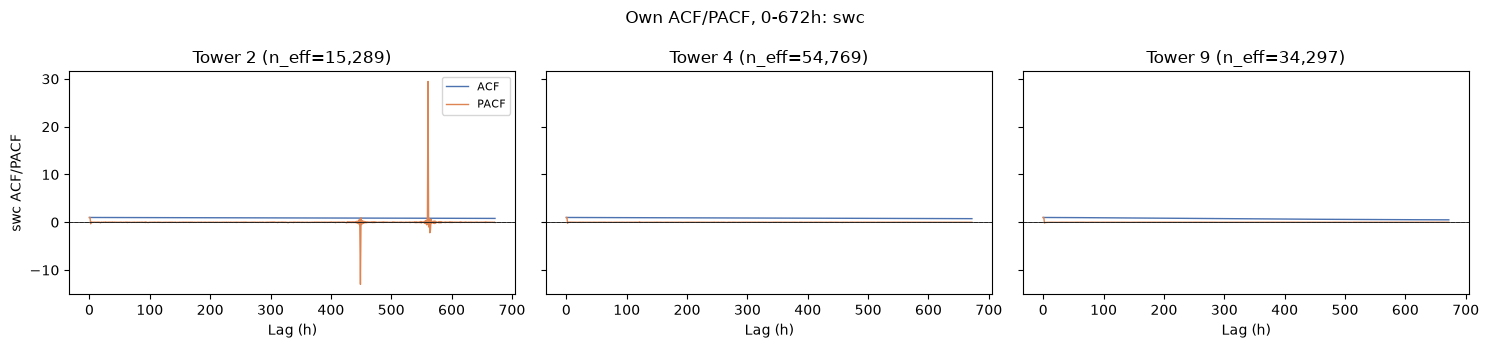

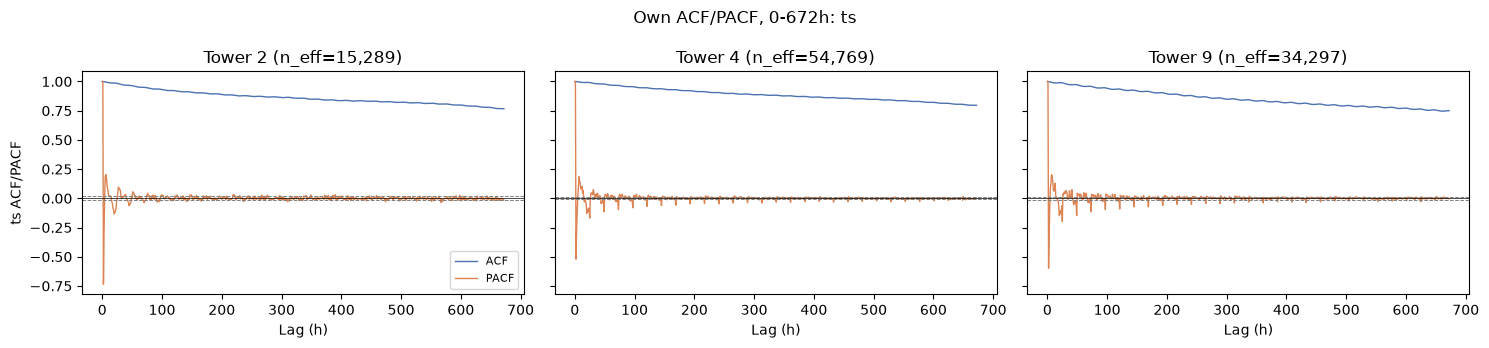

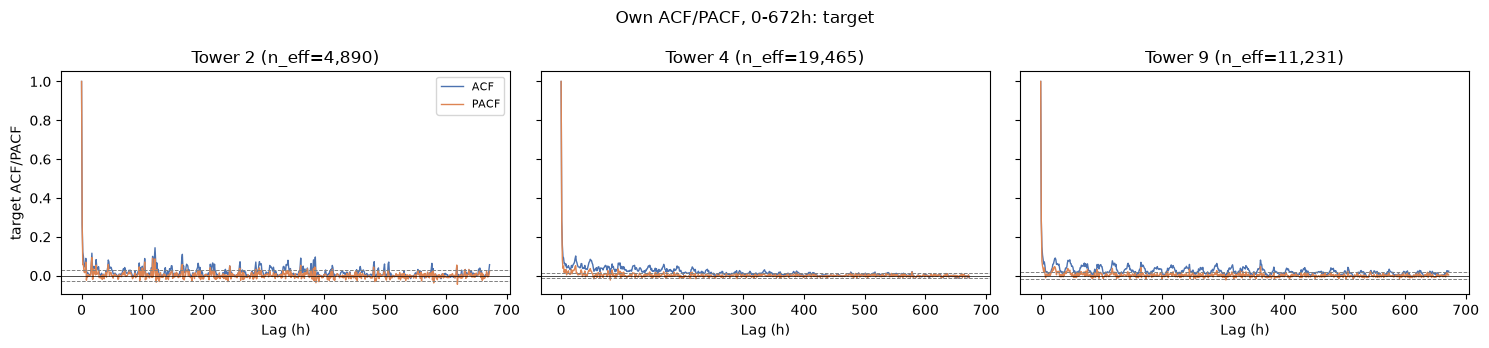

In [39]:
for var in ("swc", "ts", "target"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)
    for ax, t in zip(axes, TOWERS):
        d = ACF_DIAG[(t, var)]
        band = Z_95 / np.sqrt(max(d["n_eff"], 2))
        lags = np.arange(len(d["acf"]))
        ax.plot(lags, d["acf"], color="#4C72B0", lw=1, label="ACF")
        ax.plot(lags, d["pacf"], color="#DD8452", lw=1, label="PACF")
        ax.axhline(band, color="grey", ls="--", lw=0.7); ax.axhline(-band, color="grey", ls="--", lw=0.7)
        ax.axhline(0, color="black", lw=0.5)
        ax.set_title(f"Tower {t} (n_eff={d['n_eff']:,})"); ax.set_xlabel("Lag (h)")
    axes[0].set_ylabel(f"{var} ACF/PACF"); axes[0].legend(fontsize=8)
    plt.suptitle(f"Own ACF/PACF, 0-{MAXLAG}h: {var}")
    plt.tight_layout(); plt.show()

### 6.3 Cross-correlation: FCH4 target vs. swc/ts, lag and lead

Computed via `pandas.Series.corr()` (pairwise-complete by construction) rather than `statsmodels.ccf`,
which has no missing-data handling -- simpler and correct here given the target's real sparsity.

In [40]:
@timeit
def cross_corr_target(target_full, covar_full, dom_bool, maxlag=MAXLAG):
    tgt = target_full[dom_bool]; cov = covar_full[dom_bool]
    lag_corr = np.array([tgt.corr(cov.shift(h)) for h in range(1, maxlag + 1)])
    lead_corr = np.array([tgt.corr(cov.shift(-h)) for h in range(1, maxlag + 1)])
    return dict(lag=lag_corr, lead=lead_corr, n_eff=int(tgt.notna().sum()))


CROSS_CORR = {}
for t in TOWERS:
    tgt_full, tgt_dm = series_for_diag(t, "target")
    for var in ("swc", "ts"):
        cov_full, _ = series_for_diag(t, var)
        CROSS_CORR[(t, var)] = cross_corr_target(tgt_full, cov_full, tgt_dm)
print("Cross-correlation computed for swc/ts x 3 towers.")

Cross-correlation computed for swc/ts x 3 towers.


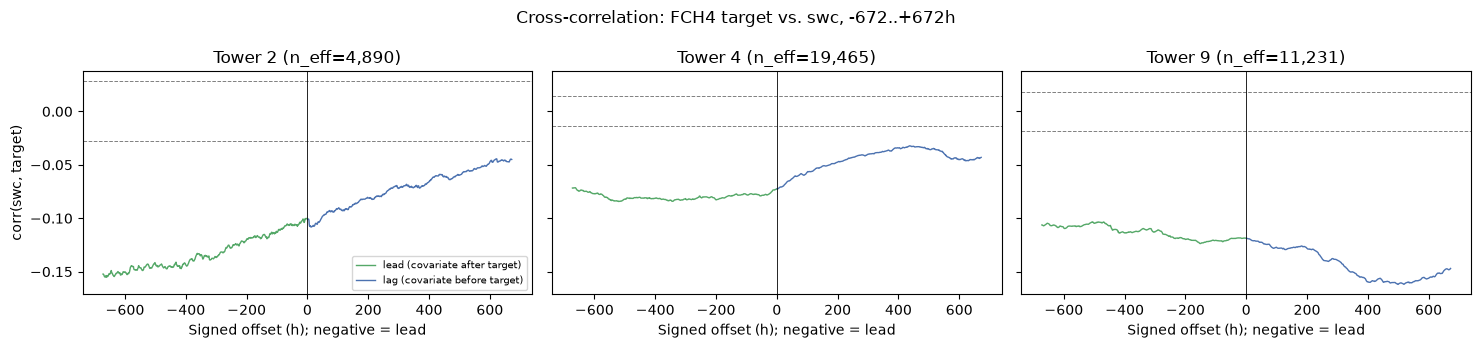

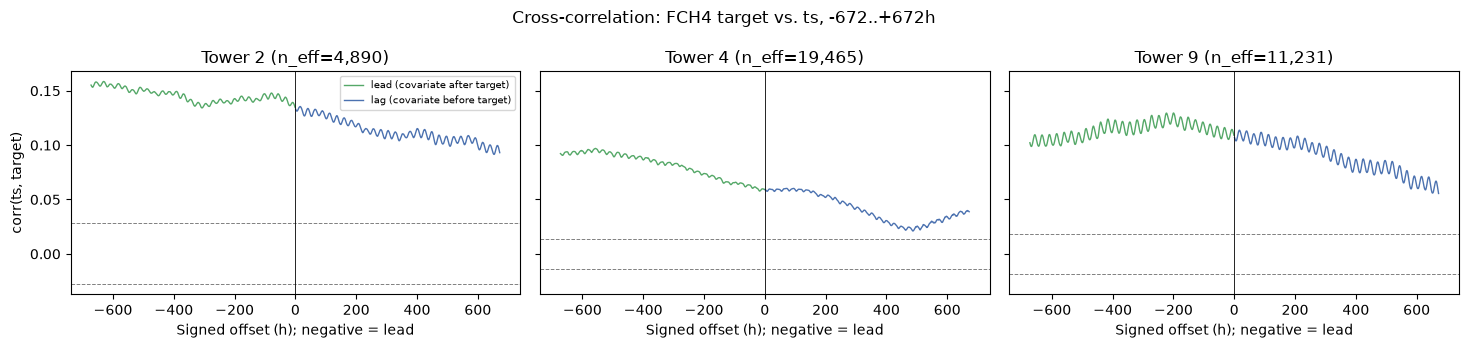

In [41]:
for var in ("swc", "ts"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)
    offsets = np.arange(1, MAXLAG + 1)
    for ax, t in zip(axes, TOWERS):
        d = CROSS_CORR[(t, var)]
        band = Z_95 / np.sqrt(max(d["n_eff"], 2))
        ax.plot(-offsets[::-1], d["lead"][::-1], color="#55A868", lw=1, label="lead (covariate after target)")
        ax.plot(offsets, d["lag"], color="#4C72B0", lw=1, label="lag (covariate before target)")
        ax.axhline(band, color="grey", ls="--", lw=0.7); ax.axhline(-band, color="grey", ls="--", lw=0.7)
        ax.axvline(0, color="black", lw=0.6)
        ax.set_title(f"Tower {t} (n_eff={d['n_eff']:,})"); ax.set_xlabel("Signed offset (h); negative = lead")
    axes[0].set_ylabel(f"corr({var}, target)"); axes[0].legend(fontsize=7)
    plt.suptitle(f"Cross-correlation: FCH4 target vs. {var}, -{MAXLAG}..+{MAXLAG}h")
    plt.tight_layout(); plt.show()

### 6.4 Relevance shortlist, AIC/BIC parsimony cutoff, and within-tower redundancy pruning

Per `(tower, variable, direction)`: (1) shortlist spaced-out local maxima of |correlation| via
`scipy.signal.find_peaks` (always including h=1); (2) fit nested `sm.OLS(target ~ cumulative shortlisted
candidates)` on a **fixed common row-subset** (so AIC/BIC are comparable across nested models) and take
`k_bic = argmin(BIC) + 1` as the primary cutoff (BIC over AIC, per this project's existing parsimony-
favoring convention at D-75/D-78); (3) greedily drop any BIC-surviving candidate that is >90% correlated
with an already-kept one. `ar_select_order(..., glob=False)` on swc/ts's own dynamics is run alongside as
**corroboration only, not a filter** -- `glob=True` at this scale is computationally infeasible (confirmed:
`ArrayMemoryError` even at `maxlag=50`, since it enumerates `2**maxlag` subsets).

In [42]:
@timeit
def relevance_shortlist(corr_by_h, hours, n_eff, min_gap, k_max):
    band = Z_95 / np.sqrt(max(n_eff, 2))
    absc = np.abs(corr_by_h)
    peak_idx, _ = find_peaks(absc, height=band, distance=min_gap)
    if len(peak_idx) == 0:
        peak_idx = np.array([int(np.argmax(absc))])   # fallback: weak signal, keep the single best lag
    ranked = sorted(peak_idx, key=lambda i: -absc[i])[:k_max]
    return sorted(set(int(hours[i]) for i in ranked) | {1})


@timeit
def ols_nested_bic(target_full, dom_bool, cand_series_dict):
    """cand_series_dict: {hour: shifted_series}, already ordered by relevance (descending)."""
    tgt = target_full[dom_bool].rename("target")
    hours = list(cand_series_dict.keys())
    cand_df = pd.DataFrame({h: s[dom_bool] for h, s in cand_series_dict.items()})
    common = pd.concat([tgt, cand_df], axis=1).dropna()
    n_common = len(common)
    if n_common < 20 or not hours:
        return dict(k_bic=min(1, len(hours)), k_aic=min(1, len(hours)), n_common=n_common, hours=hours)
    aics, bics = [], []
    for k in range(1, len(hours) + 1):
        X = sm.add_constant(common[hours[:k]].values)
        res = sm.OLS(common["target"].values, X).fit()
        aics.append(res.aic); bics.append(res.bic)
    return dict(k_bic=int(np.argmin(bics)) + 1, k_aic=int(np.argmin(aics)) + 1,
                n_common=n_common, hours=hours)


@timeit
def ar_order_bic(series_full, dom_bool, maxlag=AR_CORROB_MAXLAG):
    """Corroboration only (swc/ts own AR structure) -- glob=False is mandatory at this maxlag."""
    s = series_full[dom_bool].dropna().astype(float)
    try:
        sel = ar_select_order(s.values, maxlag=maxlag, ic="bic", glob=False, old_names=False)
        return list(sel.ar_lags) if sel.ar_lags else []
    except Exception as e:
        print(f"  ar_select_order failed ({e}); skipping corroboration for this series.")
        return []


@timeit
def corr_matrix_prune(cols_df, ranked_hours, thresh=CORR_PRUNE_THRESH):
    keep = []
    for h in ranked_hours:
        if all(abs(cols_df[h].corr(cols_df[k])) < thresh for k in keep):
            keep.append(h)
    return keep


print("relevance_shortlist / ols_nested_bic / ar_order_bic / corr_matrix_prune defined.")

relevance_shortlist / ols_nested_bic / ar_order_bic / corr_matrix_prune defined.


In [43]:
AR_OWN_ORDER = {}
for t in TOWERS:
    for var in ("swc", "ts"):
        s_full, dm = series_for_diag(t, var)
        AR_OWN_ORDER[(t, var)] = ar_order_bic(s_full, dm)
        print(f"Tower {t} {var:6s}: AR(BIC, glob=False) contiguous order -> {AR_OWN_ORDER[(t, var)]}")

Tower 2 swc   : AR(BIC, glob=False) contiguous order -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]


Tower 2 ts    : AR(BIC, glob=False) contiguous order -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]


Tower 4 swc   : AR(BIC, glob=False) contiguous order -> [1, 2]


Tower 4 ts    : AR(BIC, glob=False) contiguous order -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80]


Tower 9 swc   : AR(BIC, glob=False) contiguous order -> [1, 2, 3, 4, 5, 6, 7]


Tower 9 ts    : AR(BIC, glob=False) contiguous order -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85]


In [44]:
hours_arr = np.arange(1, MAXLAG + 1)
PER_TOWER_FINAL = {}
PER_TOWER_RELEVANCE = {}

for t in TOWERS:
    tgt_full, tgt_dm = series_for_diag(t, "target")
    for var, direction in VARS_DIRS:
        if var in ("swc", "ts"):
            cov_full, dm = series_for_diag(t, var)
            corr_by_h = CROSS_CORR[(t, var)]["lag" if direction == "lag" else "lead"]
            n_eff = CROSS_CORR[(t, var)]["n_eff"]
        else:   # target: self-ACF used for both directions (approximate direction-symmetry
                # assumption for a locally stationary series -- see section 6 intro)
            cov_full, dm = tgt_full, tgt_dm
            corr_by_h = ACF_DIAG[(t, "target")]["acf"][1:]
            n_eff = ACF_DIAG[(t, "target")]["n_eff"]

        shortlist = relevance_shortlist(corr_by_h, hours_arr, n_eff, MIN_GAP[var], K_SHORTLIST)
        shortlist_sorted = sorted(shortlist, key=lambda h: -abs(corr_by_h[h - 1]))

        sign = 1 if direction == "lag" else -1
        cand_series = {h: cov_full.shift(sign * h) for h in shortlist_sorted}

        bic_res = ols_nested_bic(tgt_full, dm, cand_series)
        k_bic = max(bic_res["k_bic"], 1)
        bic_survivors = bic_res["hours"][:k_bic]

        cols_df = pd.DataFrame({h: cand_series[h][dm] for h in bic_survivors})
        pruned = corr_matrix_prune(cols_df, bic_survivors)

        PER_TOWER_FINAL[(t, var, direction)] = pruned
        for h in shortlist_sorted:
            PER_TOWER_RELEVANCE[(t, var, direction, h)] = abs(float(corr_by_h[h - 1]))

        flag = "  [low-confidence: thin n_common]" if bic_res["n_common"] < 200 else ""
        print(f"T{t} {var:6s} {direction:4s}: shortlist={shortlist_sorted} -> BIC k={k_bic} "
              f"(n_common={bic_res['n_common']}){flag} -> pruned={pruned}")

T2 swc    lag : shortlist=[12, 22, 32, 38, 1, 56, 65, 86, 77, 71, 116, 133, 106, 98, 143, 151] -> BIC k=6 (n_common=4890) -> pruned=[12]


T2 swc    lead: shortlist=[660, 635, 614, 593, 650, 628, 620, 602, 542, 560, 566, 464, 415, 518, 512, 1] -> BIC k=1 (n_common=4890) -> pruned=[660]
T2 ts     lag : shortlist=[16, 41, 1, 65, 89, 112, 136, 160, 185, 208, 232, 401, 257, 425, 281, 305] -> BIC k=1 (n_common=4890) -> pruned=[16]
T2 ts     lead: shortlist=[630, 656, 582, 609, 560, 511, 489, 536, 436, 391, 464, 414, 79, 101, 57, 1] -> BIC k=1 (n_common=4890) -> pruned=[630]
T2 target lag : shortlist=[1, 121, 17, 166, 117, 385, 361, 7, 104, 24, 382, 44, 340, 293, 482, 261] -> BIC k=1 (n_common=0)  [low-confidence: thin n_common] -> pruned=[1]
T2 target lead: shortlist=[1, 121, 17, 166, 117, 385, 361, 7, 104, 24, 382, 44, 340, 293, 482, 261] -> BIC k=1 (n_common=0)  [low-confidence: thin n_common] -> pruned=[1]


T4 swc    lag : shortlist=[2, 1, 14, 41, 64, 89, 104, 112, 130, 138, 161, 153, 172, 188, 207, 214] -> BIC k=5 (n_common=19465) -> pruned=[2]
T4 swc    lead: shortlist=[520, 344, 513, 534, 528, 357, 544, 316, 310, 199, 296, 334, 281, 369, 379, 1] -> BIC k=1 (n_common=19465) -> pruned=[520]
T4 ts     lag : shortlist=[72, 95, 15, 40, 112, 119, 24, 1, 137, 159, 184, 207, 231, 256, 279, 303] -> BIC k=1 (n_common=19465) -> pruned=[72]
T4 ts     lead: shortlist=[557, 581, 533, 603, 628, 651, 510, 484, 461, 433, 411, 390, 384, 365, 338, 1] -> BIC k=1 (n_common=19465) -> pruned=[557]
T4 target lag : shortlist=[1, 24, 48, 97, 6, 33, 84, 169, 146, 121, 73, 39, 17, 12, 191, 77] -> BIC k=1 (n_common=1)  [low-confidence: thin n_common] -> pruned=[1]
T4 target lead: shortlist=[1, 24, 48, 97, 6, 33, 84, 169, 146, 121, 73, 39, 17, 12, 191, 77] -> BIC k=1 (n_common=3)  [low-confidence: thin n_common] -> pruned=[1]


T9 swc    lag : shortlist=[500, 518, 494, 474, 538, 544, 480, 407, 452, 398, 459, 553, 422, 562, 593, 1] -> BIC k=1 (n_common=11231) -> pruned=[500]
T9 swc    lead: shortlist=[151, 145, 136, 77, 125, 115, 87, 69, 97, 104, 175, 169, 62, 181, 200, 1] -> BIC k=1 (n_common=11231) -> pruned=[151]
T9 ts     lag : shortlist=[17, 41, 89, 64, 112, 208, 136, 161, 1, 185, 232, 256, 280, 304, 328, 352] -> BIC k=1 (n_common=11231) -> pruned=[17]
T9 ts     lead: shortlist=[200, 223, 271, 248, 177, 152, 415, 296, 128, 319, 392, 367, 343, 439, 103, 1] -> BIC k=1 (n_common=11231) -> pruned=[200]
T9 target lag : shortlist=[1, 24, 48, 362, 45, 118, 6, 165, 72, 144, 122, 290, 27, 77, 30, 245] -> BIC k=1 (n_common=1)  [low-confidence: thin n_common] -> pruned=[1]
T9 target lead: shortlist=[1, 24, 48, 362, 45, 118, 6, 165, 72, 144, 122, 290, 27, 77, 30, 245] -> BIC k=1 (n_common=1)  [low-confidence: thin n_common] -> pruned=[1]


### 6.5 Combine per-tower recommendations into one shared lag/lead set

Towers cannot be pooled for a real correlation matrix (non-overlapping `DOMAIN`s), so hours are ranked by
(number of towers recommending, mean relevance among those towers) and walked greedily, keeping an hour
only if it is `>= min_gap` from an already-kept hour. This is a disclosed, simple stand-in for a proper
meta-analytic combination -- not a rigorous pooling, an approximation.

In [45]:
@timeit
def merge_shared_laglead(per_tower_lists, per_tower_relevance, min_gap, k_max):
    all_hours = sorted(set(h for hs in per_tower_lists.values() for h in hs))
    scored = []
    for h in all_hours:
        towers_with_h = [t for t, hs in per_tower_lists.items() if h in hs]
        mean_rel = float(np.mean([per_tower_relevance.get((t, h), 0.0) for t in towers_with_h]))
        scored.append((h, len(towers_with_h), mean_rel))
    scored.sort(key=lambda x: (-x[1], -x[2]))
    kept = []
    for h, _, _ in scored:
        if all(abs(h - k) >= min_gap for k in kept):
            kept.append(h)
        if len(kept) >= k_max:
            break
    return sorted(kept)


FINAL_LAGLEAD = {}
merge_rows = []
for var, direction in VARS_DIRS:
    per_tower = {t: PER_TOWER_FINAL[(t, var, direction)] for t in TOWERS}
    rel = {(t, h): PER_TOWER_RELEVANCE.get((t, var, direction, h), 0.0) for t in TOWERS for h in per_tower[t]}
    shared = merge_shared_laglead(per_tower, rel, min_gap=MIN_GAP[var], k_max=K_MAX_SHARED)
    FINAL_LAGLEAD[f"{var}_{direction}"] = shared
    merge_rows.append({"variable": var, "direction": direction, "T2": per_tower[2], "T4": per_tower[4],
                        "T9": per_tower[9],
                        "union_size": len(set(per_tower[2]) | set(per_tower[4]) | set(per_tower[9])),
                        "final_shared": shared})

MERGE_TABLE = pd.DataFrame(merge_rows)
print(MERGE_TABLE.to_string(index=False))
print("\nFINAL_LAGLEAD:", FINAL_LAGLEAD)

variable direction    T2    T4    T9  union_size    final_shared
     swc       lag  [12]   [2] [500]           3    [2, 12, 500]
     swc      lead [660] [520] [151]           3 [151, 520, 660]
      ts       lag  [16]  [72]  [17]           3        [16, 72]
      ts      lead [630] [557] [200]           3 [200, 557, 630]
  target       lag   [1]   [1]   [1]           1             [1]
  target      lead   [1]   [1]   [1]           1             [1]

FINAL_LAGLEAD: {'swc_lag': [2, 12, 500], 'swc_lead': [151, 520, 660], 'ts_lag': [16, 72], 'ts_lead': [200, 557, 630], 'target_lag': [1], 'target_lead': [1]}


### 6.6 Summary

`FINAL_LAGLEAD` above is the statistically-derived, shared candidate set -- **a candidate, not a verdict**.
Section 7 fits the actual gap-CV harness with these lags/leads and compares against the standing champion
before any adoption claim is made.

---

## 7. Empirical validation against the real gap-CV harness

Two arms, isolating covariate-vs-target effects (the exact split D-78 already showed matters): **Arm
prunedCov** (swc/ts pruned lag+lead only, zero leakage risk) and **Arm prunedFull** (prunedCov + target
pruned lag+lead, leakage-safe per-fold masking). Compared against the standing champion `RFm_pool`
(already computed in `R`, section 4.4 -- no refit needed: T2=0.576, T4=0.404, T9=0.426).

### 7.1 Frame and fit functions

`frame_pruned_cov` mirrors the source notebook's `frame_bidir` pattern (static-shift columns, no leakage
risk). `run_rf_pruned_full` mirrors the source notebook's `run_rf_target_laglead` leakage-safe pattern
(mask the fold's held-out timestamps **before** deriving `target_lagP{h}`/`target_leadP{h}`, then assert
no lag/lead references a held-out point). Column names use a `P` suffix (principled/pruned) so this
experiment's features are never confused with D-75's `swc_l{h}`/`swc_f{h}` or D-78's `target_lag{h}`/
`target_lead{h}`, even where hour values coincide.

In [46]:
@timeit
def frame_pruned_cov(t, pooled, d):
    """frame() + the shared, statistically-pruned swc/ts lag+lead columns from section 6. Target
    lag/lead are NOT added here -- they require per-fold leakage-safe masking, done in
    run_rf_pruned_full instead."""
    g = frame(t, pooled, d)
    c = cfg(t)
    swc = d[c["swc"] + "__f"] if (c["swc"] + "__f") in d.columns else d[c["swc"]]
    ts = d[c["ts"] + "__f"] if (c["ts"] + "__f") in d.columns else d[c["ts"]]
    for h in FINAL_LAGLEAD["swc_lag"]:
        g[f"swc_lagP{h}"] = swc.shift(h)
    for h in FINAL_LAGLEAD["swc_lead"]:
        g[f"swc_leadP{h}"] = swc.shift(-h)
    for h in FINAL_LAGLEAD["ts_lag"]:
        g[f"ts_lagP{h}"] = ts.shift(h)
    for h in FINAL_LAGLEAD["ts_lead"]:
        g[f"ts_leadP{h}"] = ts.shift(-h)
    return g


FEAT_PRUNED_COV = (FEATURES
                    + [f"swc_lagP{h}" for h in FINAL_LAGLEAD["swc_lag"]]
                    + [f"swc_leadP{h}" for h in FINAL_LAGLEAD["swc_lead"]]
                    + [f"ts_lagP{h}" for h in FINAL_LAGLEAD["ts_lag"]]
                    + [f"ts_leadP{h}" for h in FINAL_LAGLEAD["ts_lead"]])
FEAT_PRUNED_FULL = (FEAT_PRUNED_COV
                     + [f"target_lagP{h}" for h in FINAL_LAGLEAD["target_lag"]]
                     + [f"target_leadP{h}" for h in FINAL_LAGLEAD["target_lead"]])
print(f"baseline: {len(FEATURES)} feats | prunedCov: {len(FEAT_PRUNED_COV)} feats | "
      f"prunedFull: {len(FEAT_PRUNED_FULL)} feats")


@timeit
def run_rf_pruned_cov(t, pooled):
    """run_rf (section 4.2), generalized to frame_pruned_cov + FEAT_PRUNED_COV -- mirrors the
    source notebook's run_rf_variant pattern. No leakage risk: all columns are static shifts of
    already-gap-filled covariates, independent of the target's own held-out mask."""
    feat = FEAT_PRUNED_COV + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    frames = {tt: frame_pruned_cov(tt, pooled, d_all) for tt in towers}
    g = frames[t]; idx = g.index; out = {}; dm = dom_mask(idx, t)
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(g, "target", dm, gh):
            if len(gt) < 5:
                continue
            base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
            if pooled:
                others = []
                for tt in towers:
                    if tt == t:
                        continue
                    gg = frames[tt]; dmt = dom_mask(gg.index, tt)
                    others.append(gg[dmt & gg["target"].notna().values])
                trd = pd.concat([trd] + others, ignore_index=True)
            rf, imp = fit(feat, trd)
            yp = rf.predict(imp.transform(g.loc[gt, feat].values))
            rr.append(mets(g.loc[gt, "target"].values, yp))
        out[sc] = med_metrics(rr)
    return out


@timeit
def run_rf_pruned_full(t, pooled):
    """run_rf_target_laglead (source notebook section 20), generalized to frame_pruned_cov +
    FINAL_LAGLEAD's statistically-pruned target_lag/target_lead hours. Leakage-safe: the target
    is masked at THIS fold's held-out timestamps before target_lagP/target_leadP are derived via
    .shift(), and a runtime assertion checks every fold that no lag/lead column's source
    timestamp falls inside the held-out set."""
    target_lag_hours = FINAL_LAGLEAD["target_lag"]
    target_lead_hours = FINAL_LAGLEAD["target_lead"]
    feat = FEAT_PRUNED_FULL + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    base_frames = {tt: frame_pruned_cov(tt, pooled, d_all) for tt in towers}

    others_list = []
    if pooled:
        for tt in towers:
            if tt == t:
                continue
            gg = base_frames[tt]; dmt = dom_mask(gg.index, tt)
            gg_valid = gg[dmt & gg["target"].notna().values].copy()
            tgt_series = gg["target"]
            for h in target_lag_hours:
                gg_valid[f"target_lagP{h}"] = tgt_series.shift(h).reindex(gg_valid.index)
            for h in target_lead_hours:
                gg_valid[f"target_leadP{h}"] = tgt_series.shift(-h).reindex(gg_valid.index)
            others_list.append(gg_valid)

    g_base = base_frames[t]; idx = g_base.index; out = {}; dm = dom_mask(idx, t)
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(g_base, "target", dm, gh):
            if len(gt) < 5:
                continue
            gt_ts = pd.DatetimeIndex(gt)
            g = g_base.copy()
            target_masked = g["target"].copy()
            target_masked.loc[target_masked.index.isin(gt_ts)] = np.nan
            for h in target_lag_hours:
                g[f"target_lagP{h}"] = target_masked.shift(h)
            for h in target_lead_hours:
                g[f"target_leadP{h}"] = target_masked.shift(-h)

            for h in target_lag_hours:
                ref_ts = g.index - pd.Timedelta(hours=h)
                bad = pd.Series(ref_ts, index=g.index).isin(gt_ts) & g[f"target_lagP{h}"].notna()
                assert not bad.any(), f"leakage: target_lagP{h} (tower={t}, scenario={sc})"
            for h in target_lead_hours:
                ref_ts = g.index + pd.Timedelta(hours=h)
                bad = pd.Series(ref_ts, index=g.index).isin(gt_ts) & g[f"target_leadP{h}"].notna()
                assert not bad.any(), f"leakage: target_leadP{h} (tower={t}, scenario={sc})"

            base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
            assert not gt_ts.isin(trd.index).any(), f"leakage: held-out timestamps in training index (tower={t}, scenario={sc})"
            if pooled:
                trd = pd.concat([trd] + others_list, ignore_index=True)
            rf, imp = fit(feat, trd)
            yp = rf.predict(imp.transform(g.loc[gt, feat].values))
            rr.append(mets(g.loc[gt, "target"].values, yp))
        out[sc] = med_metrics(rr)
    return out


print("frame_pruned_cov / run_rf_pruned_cov / run_rf_pruned_full defined.")

baseline: 30 feats | prunedCov: 41 feats | prunedFull: 43 feats
frame_pruned_cov / run_rf_pruned_cov / run_rf_pruned_full defined.


### 7.2 Smoke test, then the full grid

One fold first (Tower 4, prunedFull -- the more complex arm) before committing to full 3-tower x 5-scenario
x `N_REPS=2` coverage for both arms (60 new RF fits total, all fresh cache misses since these are new
feature lists -- comparable in scale to the champion's own 30-fit computation in section 4.3, doubled only
to isolate the covariate-vs-target effect per D-78's own lesson).

In [47]:
import time
t0 = time.time()
_smoke = run_rf_pruned_full(4, pooled=True)
_smoke_r2 = np.nanmedian([_smoke[s]["R2"] for s in SCENARIOS])
print(f"Smoke test (Tower 4, prunedFull): R2={_smoke_r2:.3f}  [{time.time()-t0:.0f}s elapsed]")

Smoke test (Tower 4, prunedFull): R2=0.345  [590s elapsed]


In [48]:
import time
t0 = time.time()
RESU_PRUNED_COV = {}
print("RESU_PRUNED_COV initialized; running one tower at a time (checkpointed) below.")

RESU_PRUNED_COV initialized; running one tower at a time (checkpointed) below.


In [49]:
RESU_PRUNED_COV[2] = run_rf_pruned_cov(2, pooled=True)
print(f"done prunedCov   Tower 2  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done prunedCov   Tower 2  (   572s elapsed)


In [50]:
RESU_PRUNED_COV[4] = run_rf_pruned_cov(4, pooled=True)
print(f"done prunedCov   Tower 4  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done prunedCov   Tower 4  (  1078s elapsed)


In [51]:
RESU_PRUNED_COV[9] = run_rf_pruned_cov(9, pooled=True)
print(f"done prunedCov   Tower 9  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done prunedCov   Tower 9  (    11s elapsed)


In [52]:
RESU_PRUNED_FULL = {}
print("RESU_PRUNED_FULL initialized; running one tower at a time (checkpointed) below.")

RESU_PRUNED_FULL initialized; running one tower at a time (checkpointed) below.


In [53]:
RESU_PRUNED_FULL[2] = run_rf_pruned_full(2, pooled=True)
print(f"done prunedFull  Tower 2  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done prunedFull  Tower 2  (    15s elapsed)


In [54]:
RESU_PRUNED_FULL[4] = run_rf_pruned_full(4, pooled=True)   # Tower 4 hits the smoke-test cache
print(f"done prunedFull  Tower 4  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done prunedFull  Tower 4  (    19s elapsed)


In [55]:
RESU_PRUNED_FULL[9] = run_rf_pruned_full(9, pooled=True)
print(f"ALL DONE in {time.time()-t0:.0f}s")

ALL DONE in 23s


### 7.3 Results

In [56]:
rows = []
for arm_name, resu in [("prunedCov", RESU_PRUNED_COV), ("prunedFull", RESU_PRUNED_FULL)]:
    for t in TOWERS:
        scn = resu[t]
        ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
        rows.append({"tower": t, "model": f"RFm_pool_{arm_name}",
                     **{f"{k}_overall": round(ov[k], 3) for k in ov},
                     **{f"R2_{s}": round(scn[s]["R2"], 3) if pd.notna(scn[s]["R2"]) else np.nan for s in SCENARIOS}})
R_PRUNED = pd.DataFrame(rows)

CHAMPION_R2 = {t: R.loc[(R.tower == t) & (R.model == "RFm_pool"), "R2_overall"].iloc[0] for t in TOWERS}
R_PRUNED["champion_R2"] = R_PRUNED["tower"].map(CHAMPION_R2)
R_PRUNED["delta_R2"] = (R_PRUNED["R2_overall"] - R_PRUNED["champion_R2"]).round(3)

print(R_PRUNED[["tower", "model", "R2_overall", "champion_R2", "delta_R2"]].to_string(index=False))

DATA_DIR = Path("_data")   # already created in section 4.7; kept explicit here for a standalone rerun
DATA_DIR.mkdir(exist_ok=True)
R_PRUNED.to_csv(DATA_DIR / "lag_lead_pruned_results.csv", index=False)
print(f"\nSaved {DATA_DIR/'lag_lead_pruned_results.csv'}")
R_PRUNED

 tower               model  R2_overall  champion_R2  delta_R2
     2  RFm_pool_prunedCov       0.574        0.576    -0.002
     4  RFm_pool_prunedCov       0.406        0.404     0.002
     9  RFm_pool_prunedCov       0.409        0.426    -0.017
     2 RFm_pool_prunedFull       0.498        0.576    -0.078
     4 RFm_pool_prunedFull       0.342        0.404    -0.062
     9 RFm_pool_prunedFull       0.359        0.426    -0.067

Saved _data\lag_lead_pruned_results.csv


,tower,model,R2_overall,RMSE_overall,MAE_overall,MBE_overall,R2_vs,R2_s,R2_m,R2_l,R2_m1,champion_R2,delta_R2
0,2,RFm_pool_prunedCov,0.574,76.150,31.293,3.681,0.574,0.727,0.699,0.290,0.542,0.576,-0.002
1,4,RFm_pool_prunedCov,0.406,101.668,42.795,3.692,0.427,0.426,0.406,0.248,0.330,0.404,0.002
2,9,RFm_pool_prunedCov,0.409,108.192,49.594,0.641,0.453,0.363,0.409,0.222,0.424,0.426,-0.017
3,2,RFm_pool_prunedFull,0.498,83.508,33.206,2.898,0.498,0.654,0.639,0.221,0.458,0.576,-0.078
4,4,RFm_pool_prunedFull,0.342,102.012,43.730,3.218,0.443,0.399,0.342,0.243,0.306,0.404,-0.062
5,9,RFm_pool_prunedFull,0.359,109.462,48.953,-1.240,0.414,0.310,0.365,0.210,0.359,0.426,-0.067


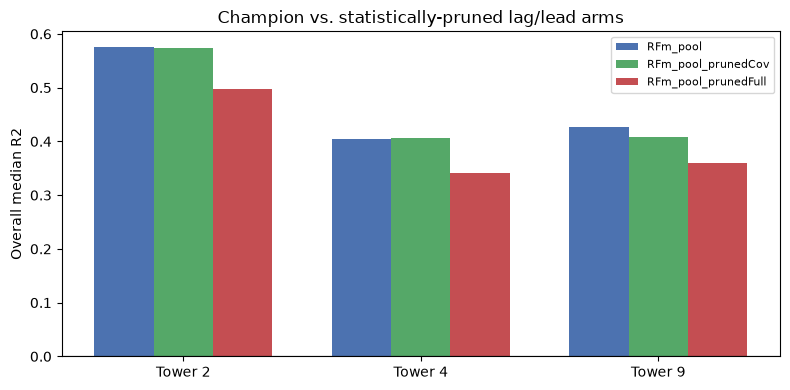

In [57]:
fig, ax = plt.subplots(figsize=(8, 4))
width = 0.25
models = ["RFm_pool", "RFm_pool_prunedCov", "RFm_pool_prunedFull"]
colors = {"RFm_pool": "#4C72B0", "RFm_pool_prunedCov": "#55A868", "RFm_pool_prunedFull": "#C44E52"}
xpos = np.arange(len(TOWERS))
for i, m in enumerate(models):
    if m == "RFm_pool":
        vals = [CHAMPION_R2[t] for t in TOWERS]
    else:
        vals = [R_PRUNED.loc[(R_PRUNED.tower == t) & (R_PRUNED.model == m), "R2_overall"].iloc[0] for t in TOWERS]
    ax.bar(xpos + (i - 1) * width, vals, width, label=m, color=colors[m])
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(xpos); ax.set_xticklabels([f"Tower {t}" for t in TOWERS])
ax.set_ylabel("Overall median R2"); ax.set_title("Champion vs. statistically-pruned lag/lead arms")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### 7.4 Discussion

State the outcome plainly either way, using the same noise-band framing already established at D-75/D-78
(deltas inside roughly ±0.01-0.02 are within this notebook's documented cross-run noise, not a real signal
regardless of which side of zero they land on):

- **If `prunedCov`/`prunedFull` beat the champion outside noise at all 3 towers**: the more rigorous,
  statistically-derived lag/lead set is a genuine improvement over the a priori `LAG_HOURS` grid, and is a
  concrete candidate to adopt into `frame()`/`FEATURES` in a future session.
- **If deltas are inside noise or negative (matching D-75/D-78's own prior pattern)**: this confirms --
  now via a principled, auditable method rather than another a priori guess -- that the pooled RFm
  architecture already captures whatever soil-moisture/temperature/target memory is extractable from these
  variables (via the current `FEATURES` set's cyclical time features, current-timestep drivers, GPP/Reco,
  and livestock density), and no further lag/lead engineering on these three variables is worth pursuing.

Either way, this section's real contribution is the auditable `FINAL_LAGLEAD` derivation itself (section
6), not just the empirical delta -- if a future session wants to revisit this with a different `MAXLAG`,
`K_MAX_SHARED`, or pruning threshold, the diagnostics in section 6 are reusable without re-deriving the
methodology.

---

## 8. Timing summary

Aggregate wall-clock time spent inside every `@timeit`-decorated function across the whole notebook run, sorted by total time descending -- useful for spotting the next bottleneck before it causes another multi-hour surprise (this session's `ar_select_order` incident, section 6, being the motivating example).

In [58]:
print_timing_summary()

function                            calls    total_s     avg_ms
reconstruct_fc                          3     181.23   60409.77
dissimilarity_index                     4      35.83    8957.96
fit                                   137      26.90     196.32
ar_order_bic                            6      19.91    3318.09
run_rf                                  6      17.37    2895.05
run_rf_pruned_full                      4      15.32    3831.05
eval_driver_gapfill                    33      14.06     426.00
run_rf_pruned_cov                       3      11.35    3783.84
mdc_gapfill                           363      10.23      28.18
frame                                  58       7.74     133.43
run_mds                                 3       7.36    2453.41
acf_pacf_own                            9       6.52     723.89
mds_fill_batch                         30       6.46     215.31
insert_calendar_gaps                  248       4.82      19.44
run_rf_capture                          